# Round 3 — Submission Log Analysis

Loads the `.json` (results) and `.log` (execution) files from a Prosperity round-3 submission and produces:
- the same cross-product PnL/position diagnostics as round 2 (sections 1–7), for all 12 products;
- new options-specific sections (8–12): IV reconstruction, BS-delta per voucher, **delta-hedge quality**, counterfactual hedge policies, summary.

**Change `LOG_DIR` to point at any submission folder — everything else auto-adapts.**

| File | Contents |
|---|---|
| `*.json` | `profit`, `activitiesLog`, `graphLog`, `positions` |
| `*.log`  | `submissionId`, same `activitiesLog`, `logs`, `tradeHistory` |


In [1]:
# ── CONFIG ─────────────────────────────────────────────────────────────────
LOG_DIR = "../logs/389010"   # ← change to your submission folder

# Underlying / option universe (mirrors round3/strats/trader2.py)
UNDERLYING = "VELVETFRUIT_EXTRACT"
HYDROGEL   = "HYDROGEL_PACK"
STRIKES    = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
VOUCHERS   = [f"VEV_{K}" for K in STRIKES]
VOUCHER_STRIKE = {f"VEV_{K}": K for K in STRIKES}
DEAD_VOUCHERS  = {"VEV_6000", "VEV_6500"}        # pinned mid=0.5 historically
TRADED_VOUCHERS = [v for v in VOUCHERS if v not in DEAD_VOUCHERS]

# Per-product position limits (round 3 briefing)
POSITION_LIMITS = {HYDROGEL: 200, UNDERLYING: 200, **{v: 300 for v in VOUCHERS}}

# trader2.py hedge config (for counterfactual comparison)
TRADER2_DELTA_THRESHOLD = 5
TRADER2_HEDGE_EVERY_TICKS = 1   # re-hedge each tick

# TTE config (round 3 starts at TTE=5d)
TTE_DAYS_AT_ROUND_START = 5
TICKS_PER_DAY = 1_000_000
TRADING_DAYS_PER_YEAR = 365.0
IV_EMA_ALPHA = 0.1
# ───────────────────────────────────────────────────────────────────────────

In [2]:
import os, json, glob, io, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

OUTPUT_DIR = os.path.join(os.path.dirname(LOG_DIR), "..", "notebooks", "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Outputs →", os.path.abspath(OUTPUT_DIR))

Outputs → /home/jay/projects/competitions/imc-prosperity4/round3/notebooks/output


In [3]:
# ── Load files ─────────────────────────────────────────────────────────────
json_path = glob.glob(f"{LOG_DIR}/*.json")[0]
log_path  = glob.glob(f"{LOG_DIR}/*.log")[0]

with open(json_path) as f: results   = json.load(f)
with open(log_path)  as f: execution = json.load(f)

# activitiesLog → DataFrame
acts = pd.read_csv(io.StringIO(execution["activitiesLog"]), sep=";",
                   dtype={"day": int, "timestamp": int})
max_ts = acts["timestamp"].max()
acts["global_ts"] = acts["day"] * (max_ts + 100) + acts["timestamp"]

# graphLog → PnL curve
pnl_curve = pd.read_csv(io.StringIO(results["graphLog"]), sep=";")

# tradeHistory → trades (with side flags)
trades = pd.DataFrame(execution.get("tradeHistory") or [])
if len(trades) > 0:
    trades["side"] = np.where(trades["buyer"] == "SUBMISSION", "BUY",
                       np.where(trades["seller"] == "SUBMISSION", "SELL", "OTHER"))
    trades["signed_qty"] = np.where(trades["side"] == "BUY", trades["quantity"],
                            np.where(trades["side"] == "SELL", -trades["quantity"], 0))
else:
    trades = pd.DataFrame(columns=["timestamp","buyer","seller","symbol","currency",
                                    "price","quantity","side","signed_qty"])

final_pos = {p["symbol"]: p["quantity"] for p in results.get("positions", [])}
products  = sorted(acts["product"].unique())
sub_trades = trades[trades["side"].isin(["BUY","SELL"])]

run_info = (
    f"Submission : {execution.get('submissionId','?')}\n"
    f"Round      : {results.get('round')}  |  Status: {results.get('status')}\n"
    f"Total PnL  : {(results.get('profit') or 0):.4f} XIRECS\n"
    f"Trades     : total={len(trades)}  submission={len(sub_trades)}\n"
    f"Products   : {products}\n"
    f"Final pos  : {final_pos}\n"
)
print(run_info)
with open(f"{OUTPUT_DIR}/results_00_run_info.txt", "w") as f:
    f.write(run_info)

Submission : 53f9df0a-b3e4-4589-bea7-958d2f1e383d
Round      : 3  |  Status: FINISHED
Total PnL  : 503.4414 XIRECS
Trades     : total=201  submission=90
Products   : ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
Final pos  : {'HYDROGEL_PACK': -7, 'VELVETFRUIT_EXTRACT': -69, 'VEV_4000': 37, 'VEV_4500': 32, 'XIRECS': 362222}



---
## 1. Cumulative PnL Curve

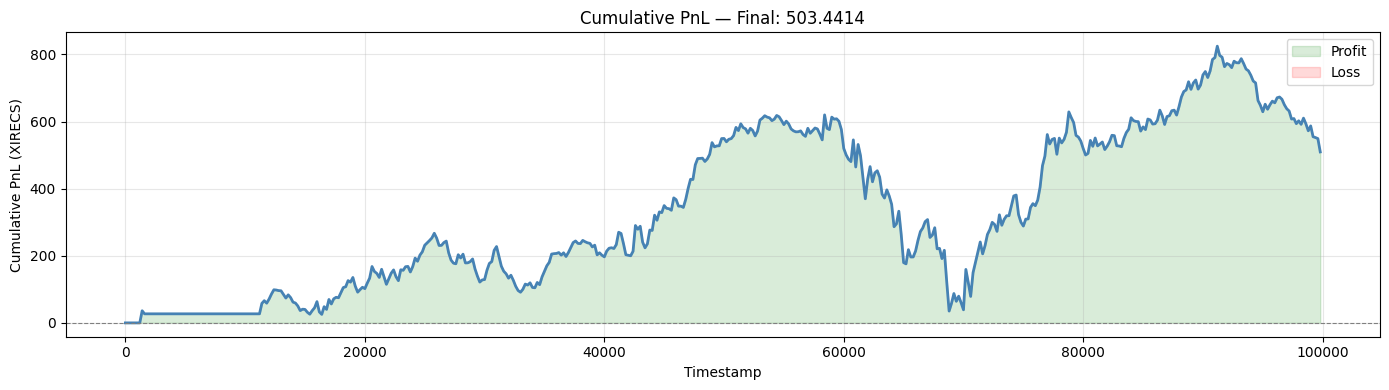

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pnl_curve["timestamp"], pnl_curve["value"], linewidth=2, color="steelblue")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.fill_between(pnl_curve["timestamp"], pnl_curve["value"], 0,
                where=pnl_curve["value"] >= 0, alpha=0.15, color="green", label="Profit")
ax.fill_between(pnl_curve["timestamp"], pnl_curve["value"], 0,
                where=pnl_curve["value"] < 0, alpha=0.15, color="red", label="Loss")
final_val = pnl_curve["value"].iloc[-1]
ax.set_xlabel("Timestamp"); ax.set_ylabel("Cumulative PnL (XIRECS)")
ax.set_title(f"Cumulative PnL — Final: {(results.get('profit') or 0):.4f}")
ax.legend(); plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/results_01_cumulative_pnl.png", dpi=130, bbox_inches="tight")
plt.show()

---
## 2. Mid & Spread per product
Loops over all 12 products. Vouchers `VEV_6000` / `VEV_6500` are typically pinned (DEAD); plotted for completeness.

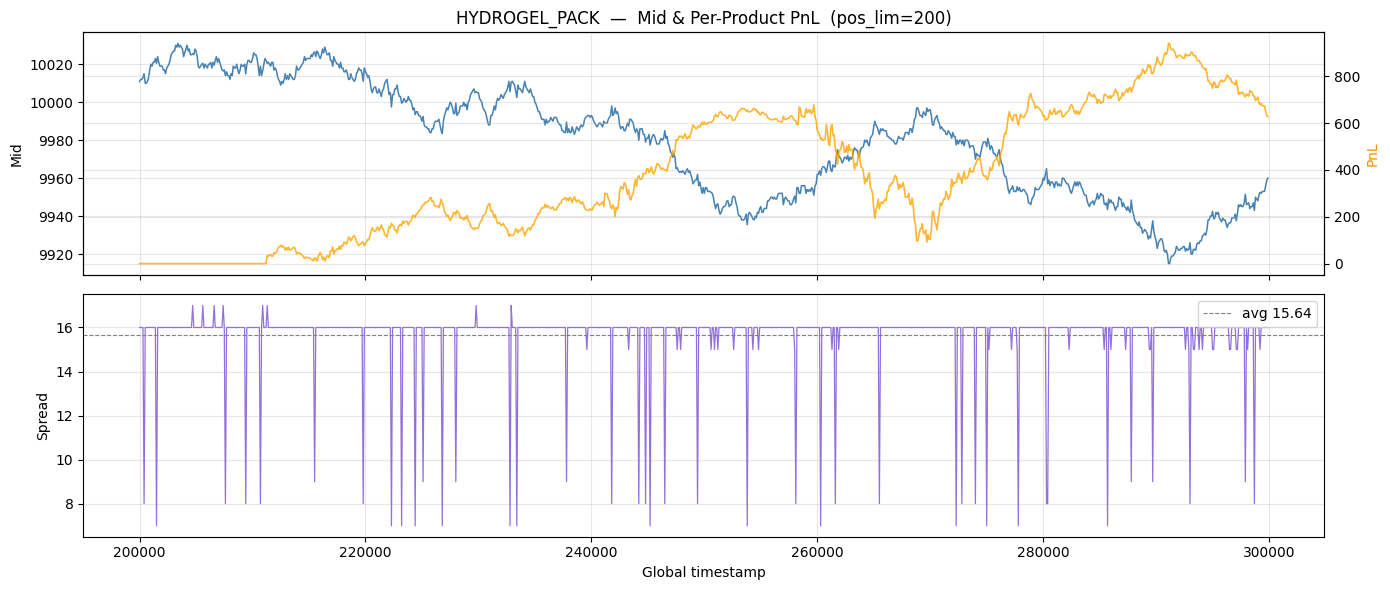

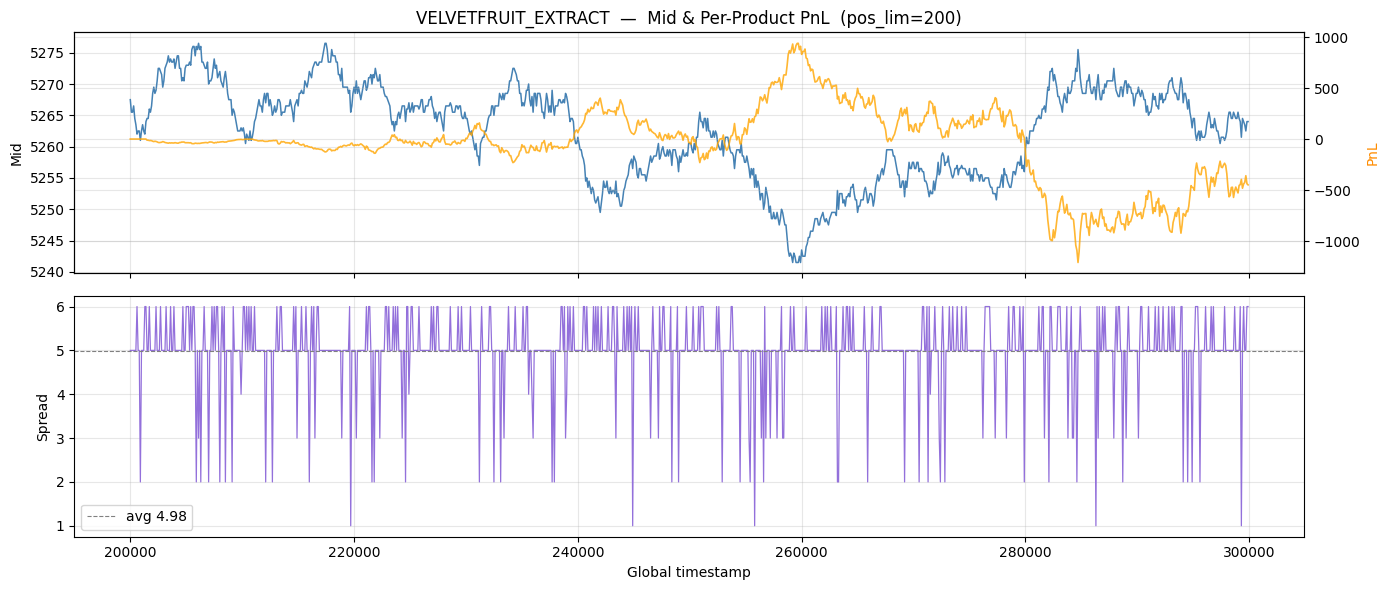

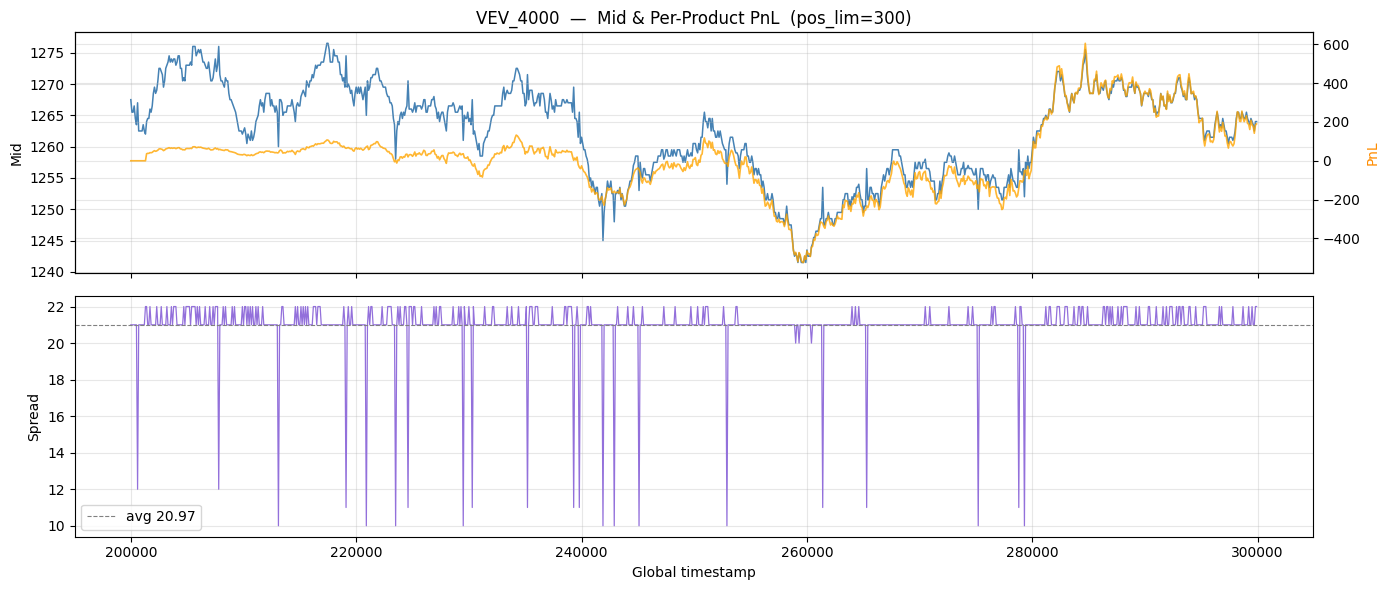

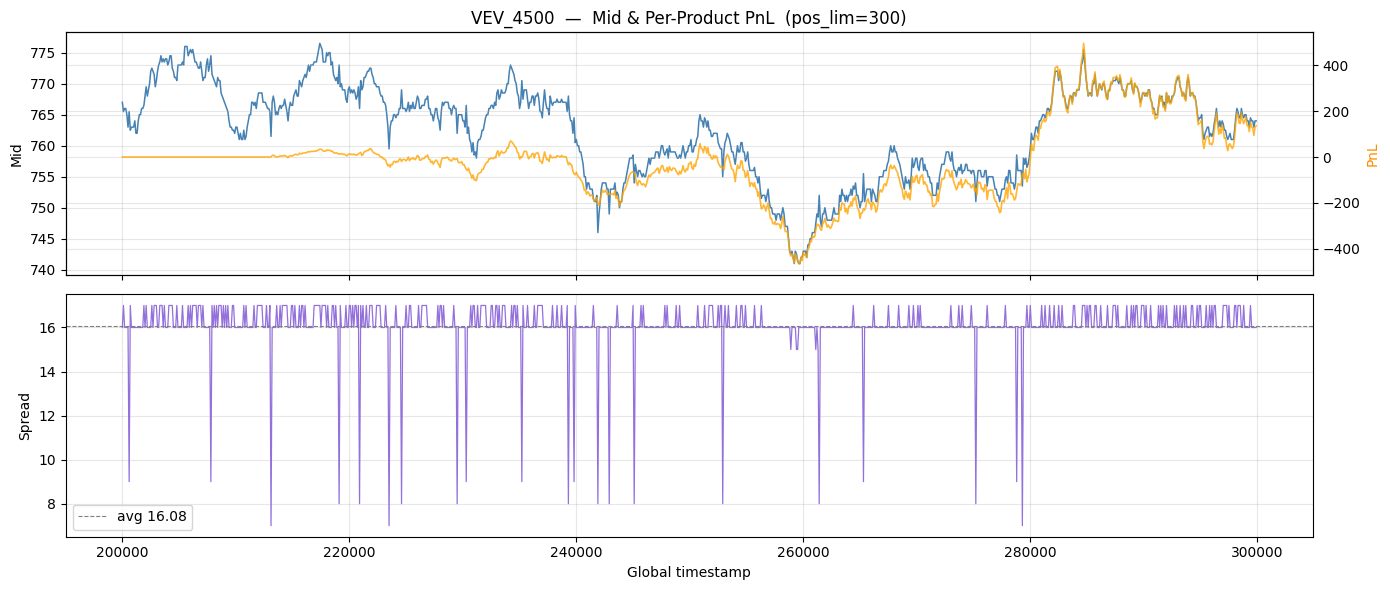

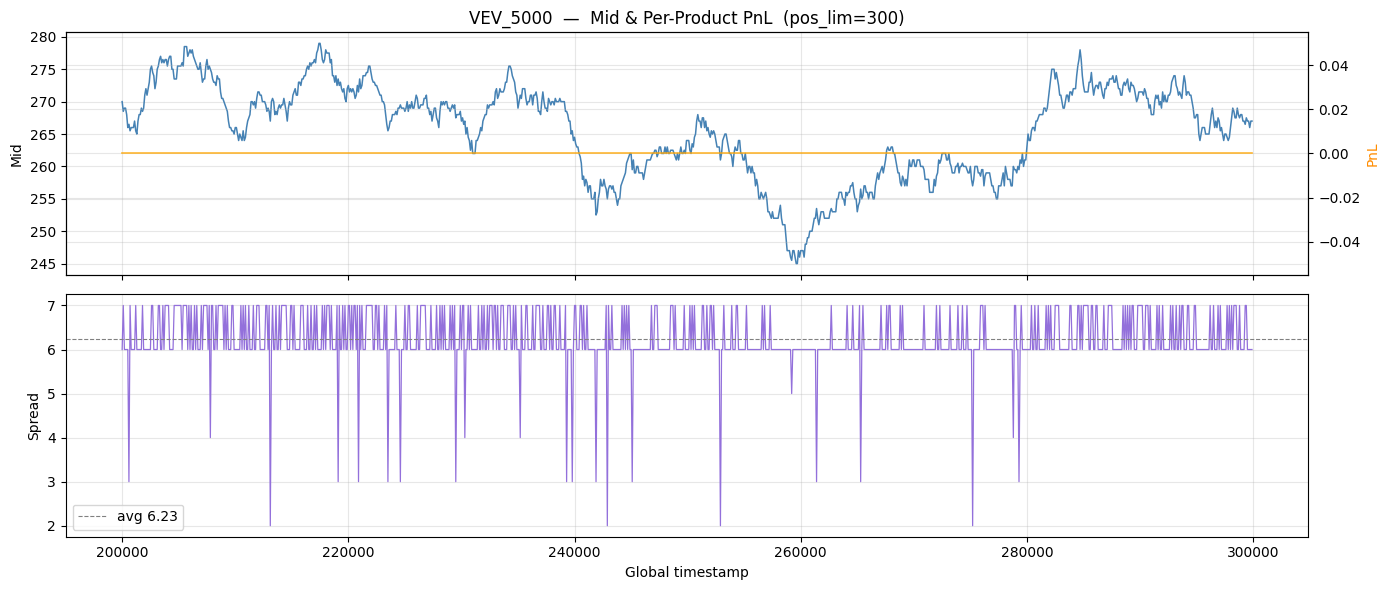

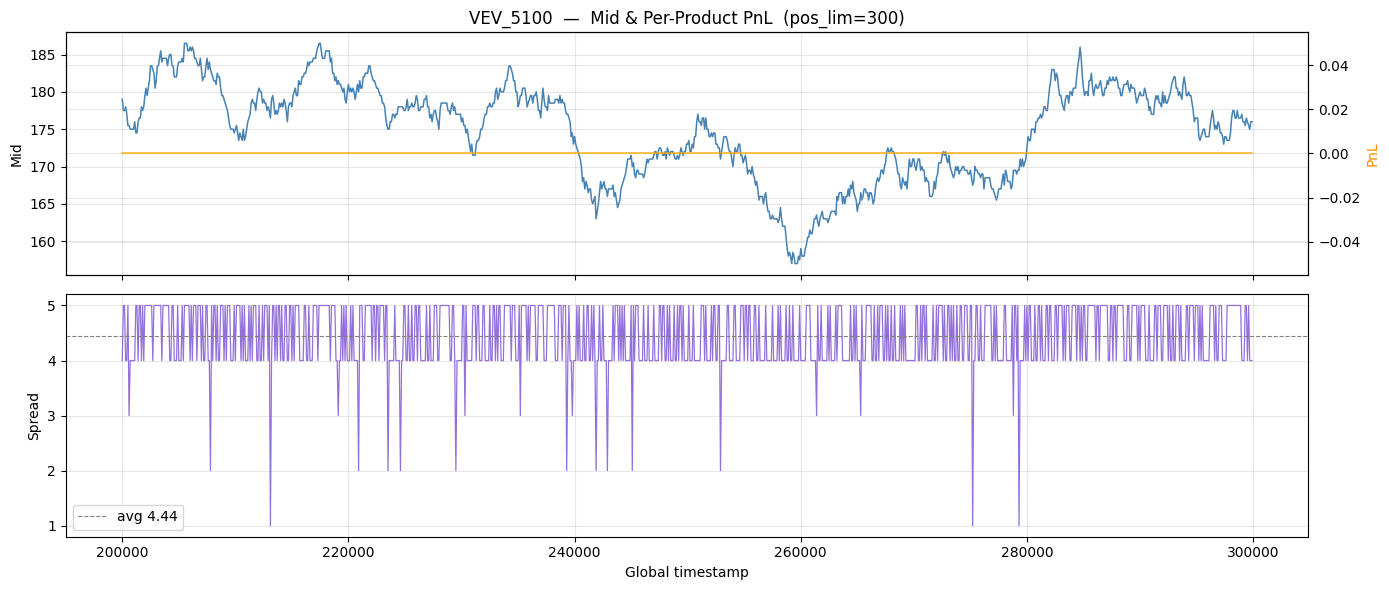

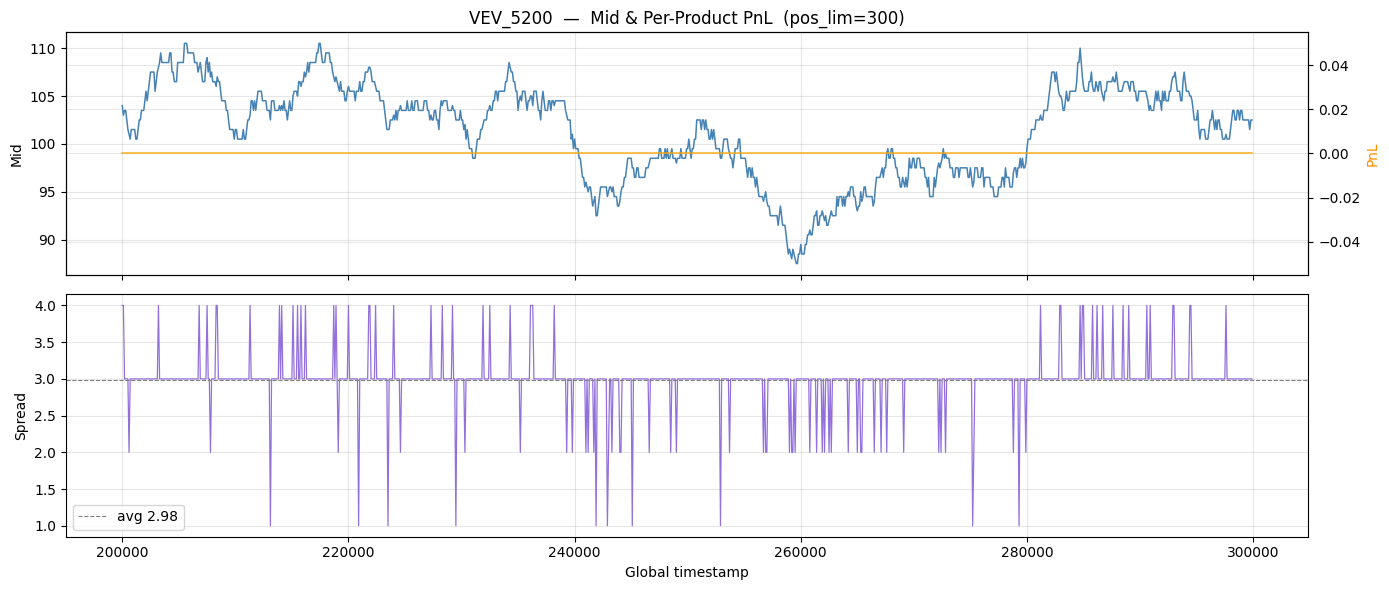

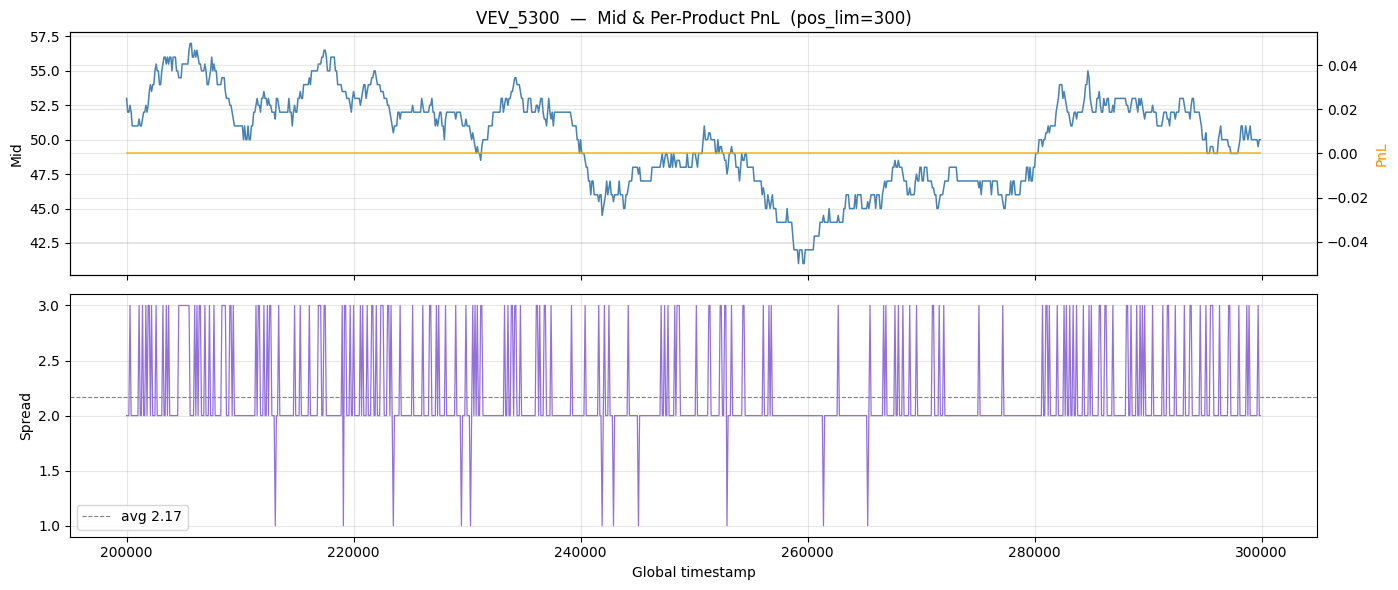

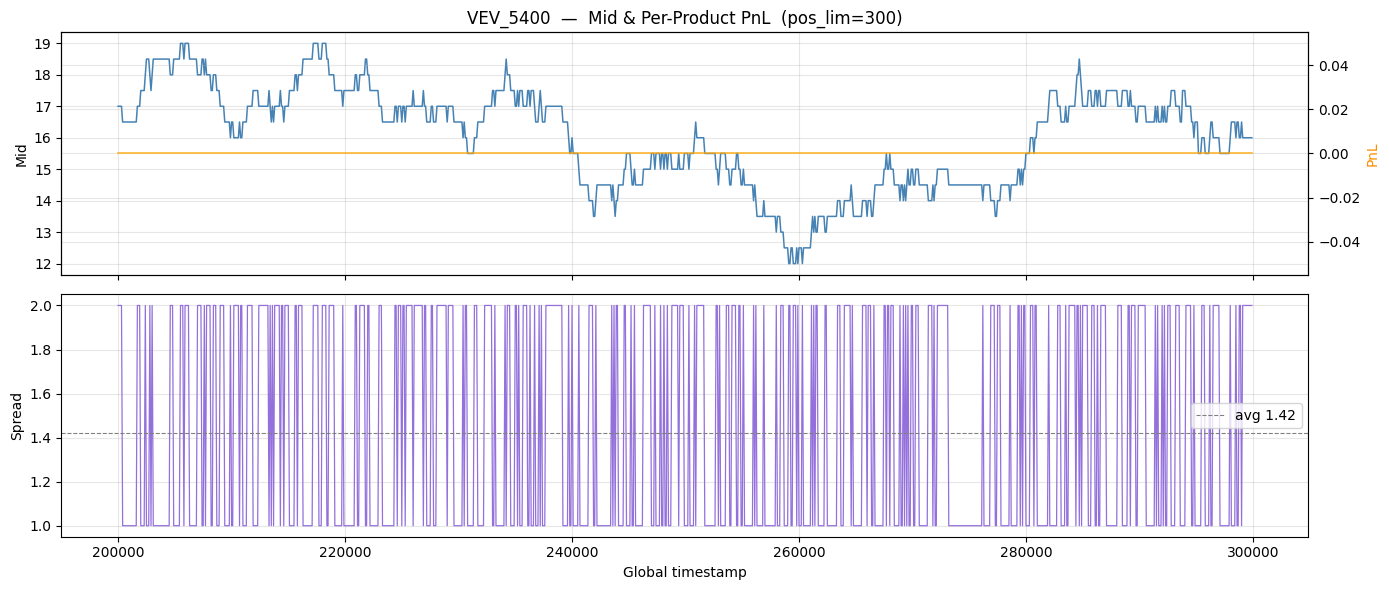

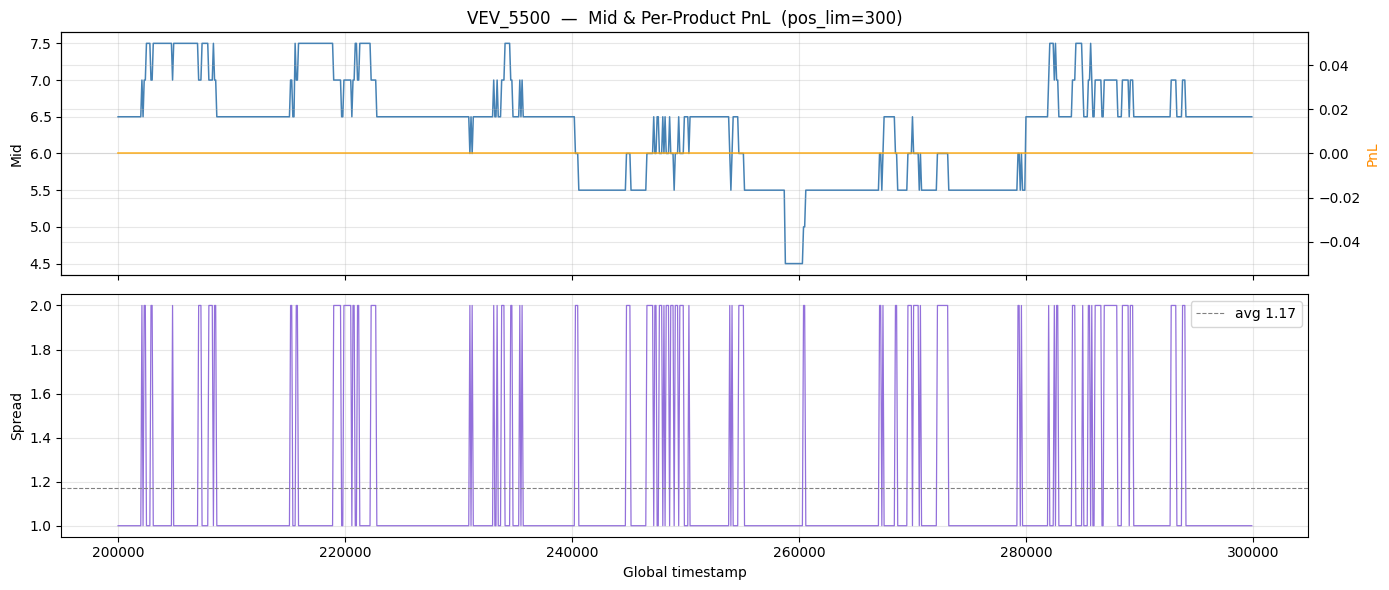

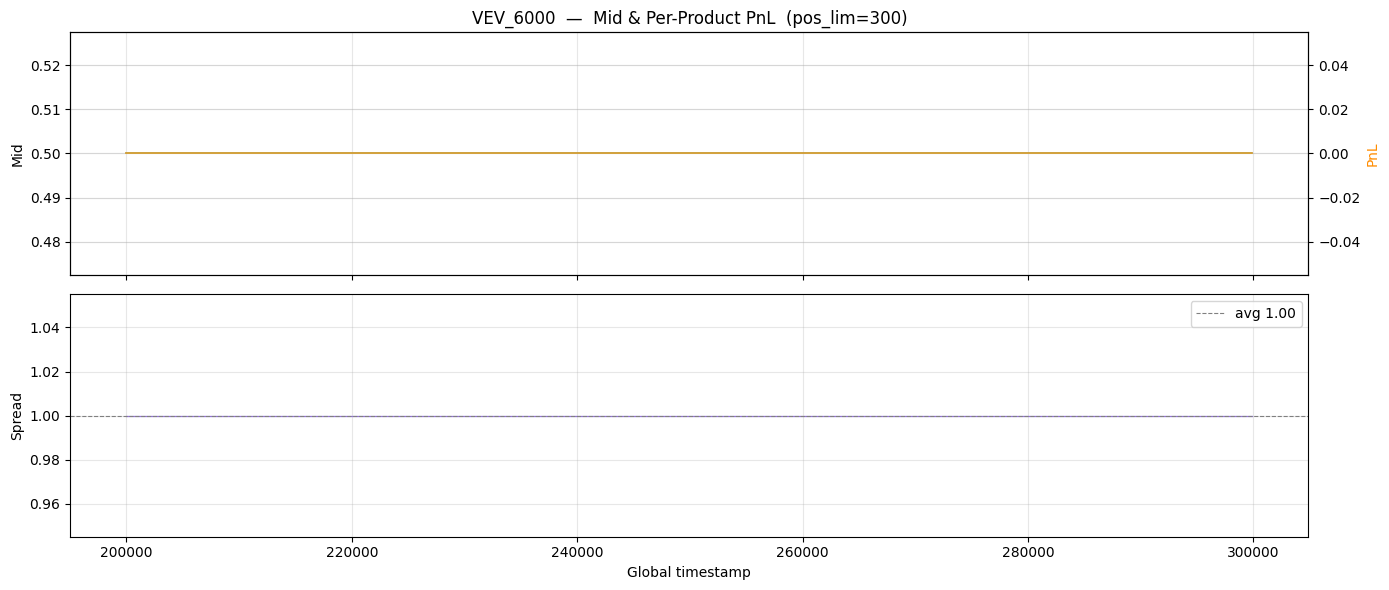

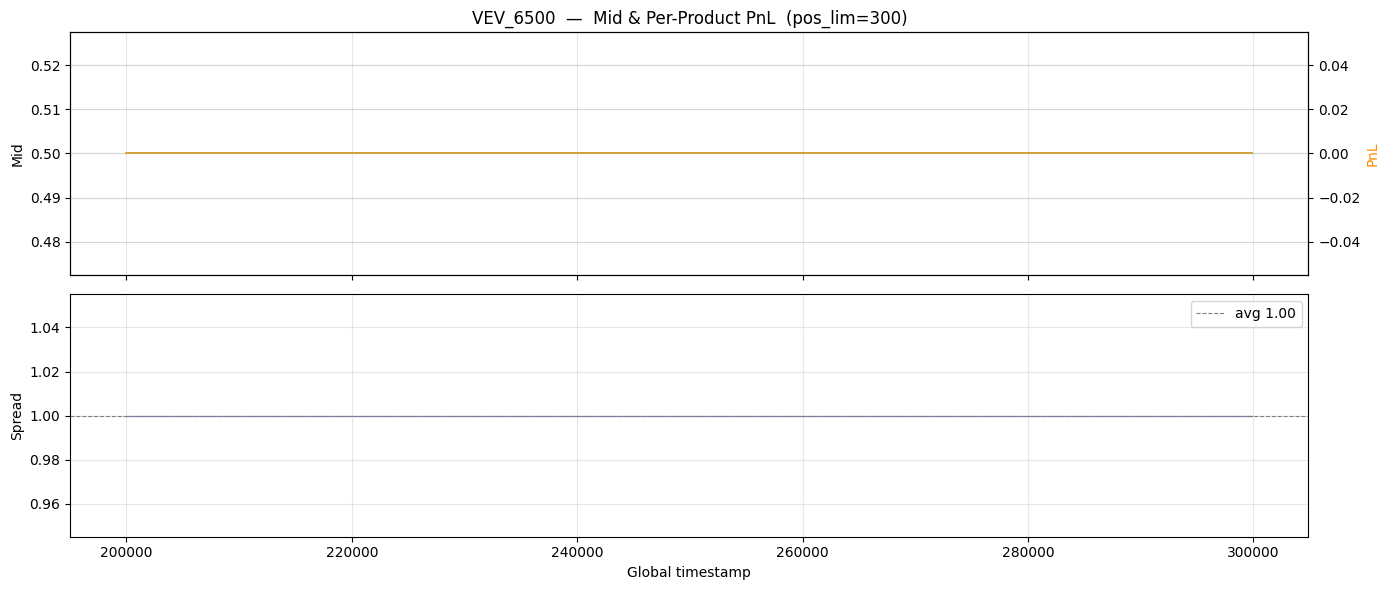

In [5]:
for product in products:
    p = acts[acts["product"] == product].copy()
    p["mid_price"] = p["mid_price"].replace(0, np.nan).ffill()
    p["spread"]    = p["ask_price_1"] - p["bid_price_1"]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    ax1.plot(p["global_ts"], p["mid_price"], color="steelblue", linewidth=1.1, label="mid")
    ax1b = ax1.twinx()
    ax1b.plot(p["global_ts"], p["profit_and_loss"], color="orange", linewidth=1.2, alpha=0.8, label="PnL")
    ax1b.set_ylabel("PnL", color="darkorange")
    ax1.set_ylabel("Mid")
    pos_lim = POSITION_LIMITS.get(product, "?")
    ax1.set_title(f"{product}  —  Mid & Per-Product PnL  (pos_lim={pos_lim})")

    ax2.plot(p["global_ts"], p["spread"], color="mediumpurple", linewidth=0.9)
    avg_sp = p["spread"].mean()
    ax2.axhline(avg_sp, color="grey", linestyle="--", linewidth=0.8, label=f"avg {avg_sp:.2f}")
    ax2.set_ylabel("Spread"); ax2.set_xlabel("Global timestamp"); ax2.legend()
    plt.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/results_02_mid_spread_{product}.png", dpi=120, bbox_inches="tight")
    plt.show()

---
## 3. Trade execution overlay per product
Blue ▲ = SUBMISSION buy, Red ▼ = SUBMISSION sell, grey × = market (other-vs-other) trades.

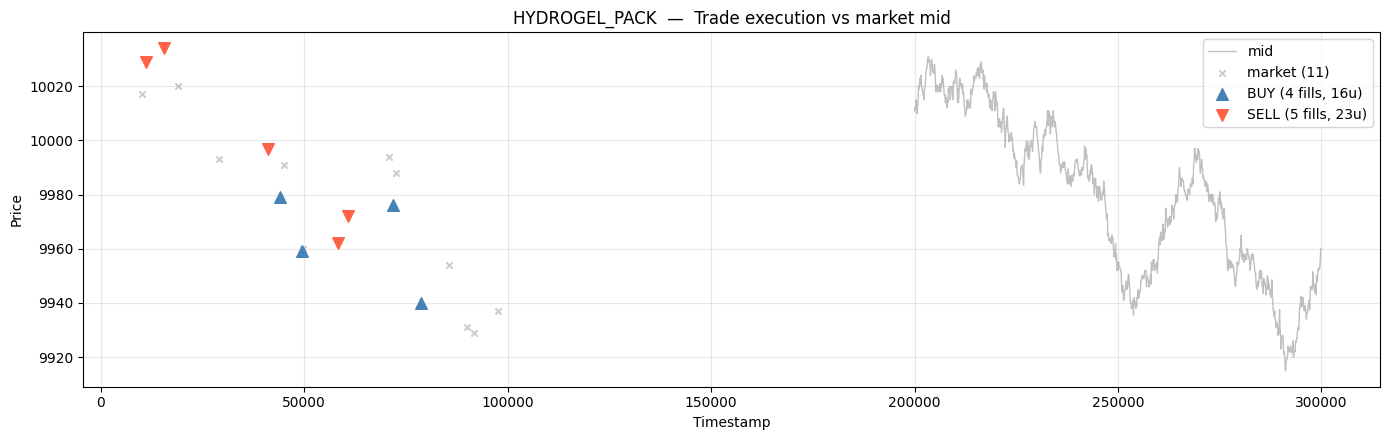

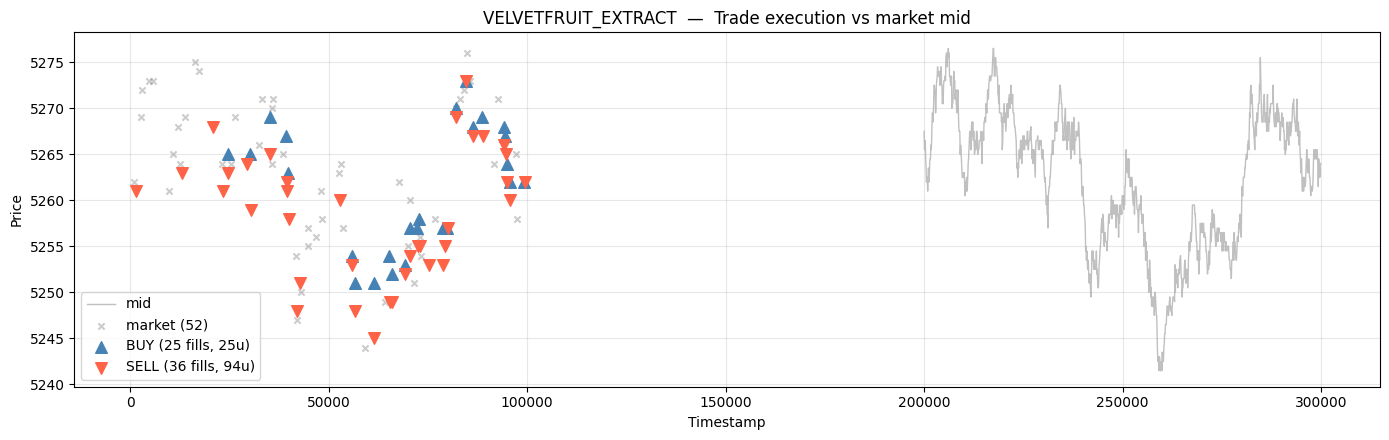

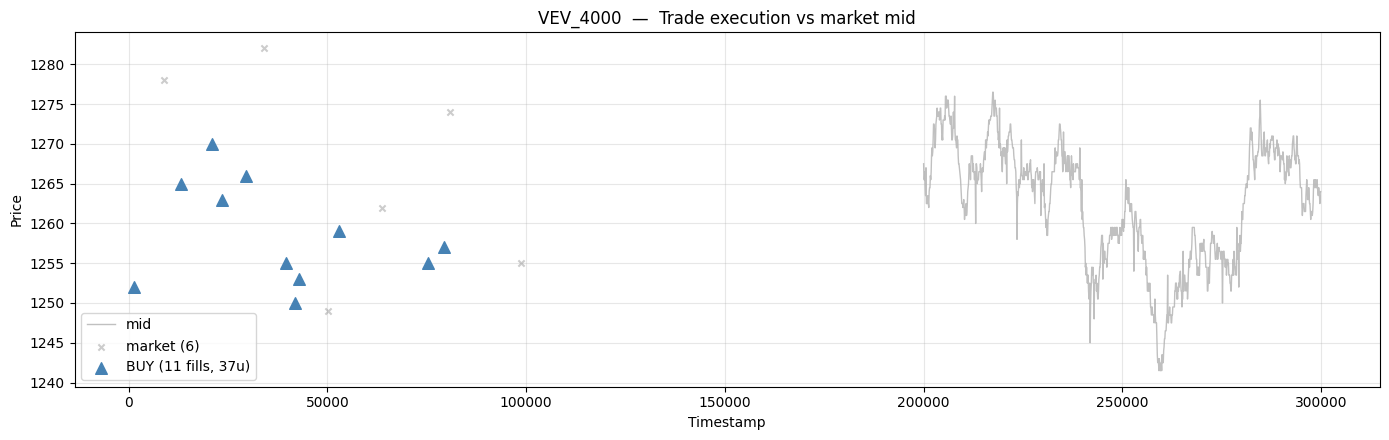

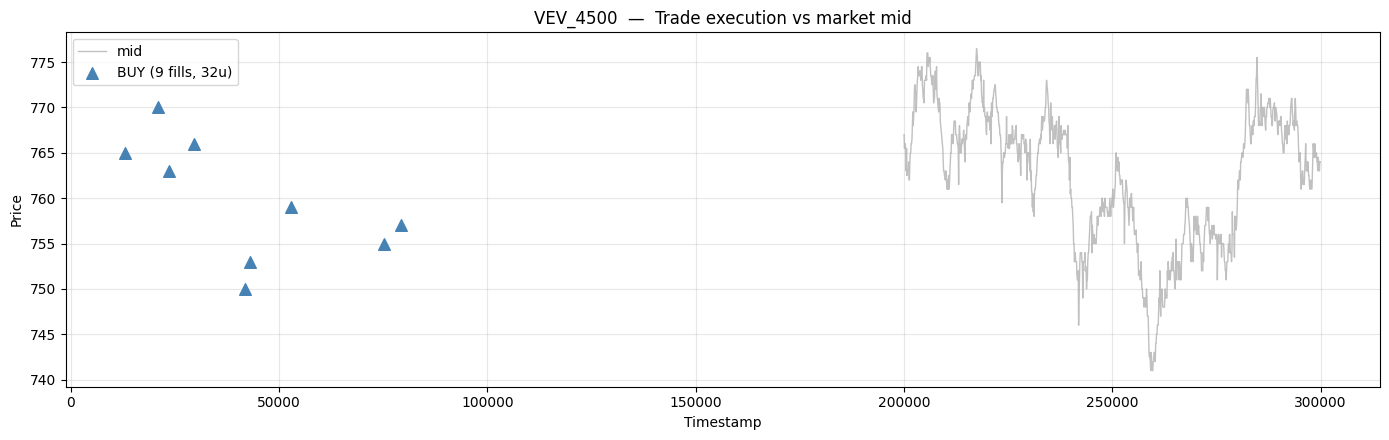

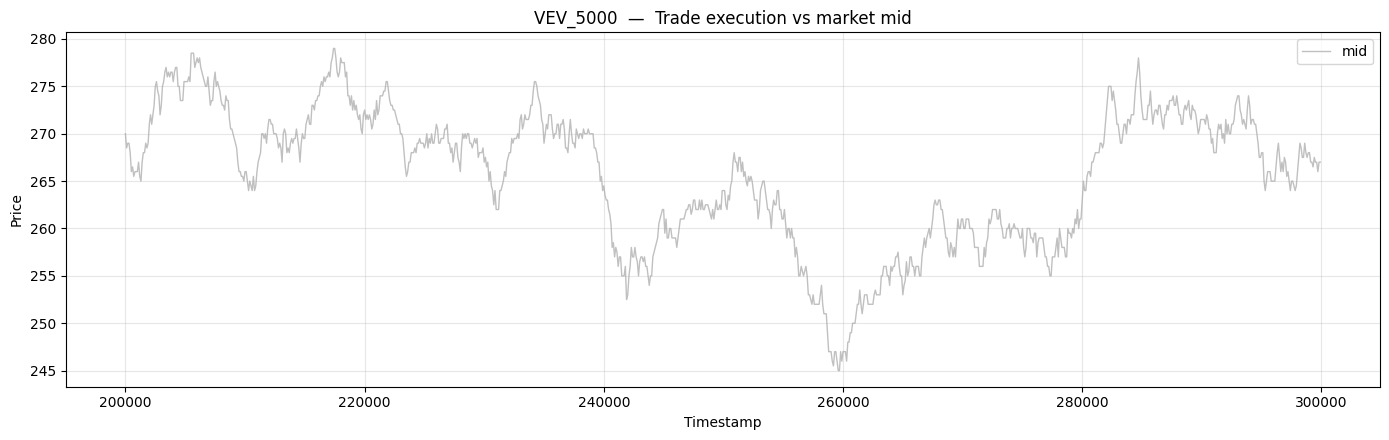

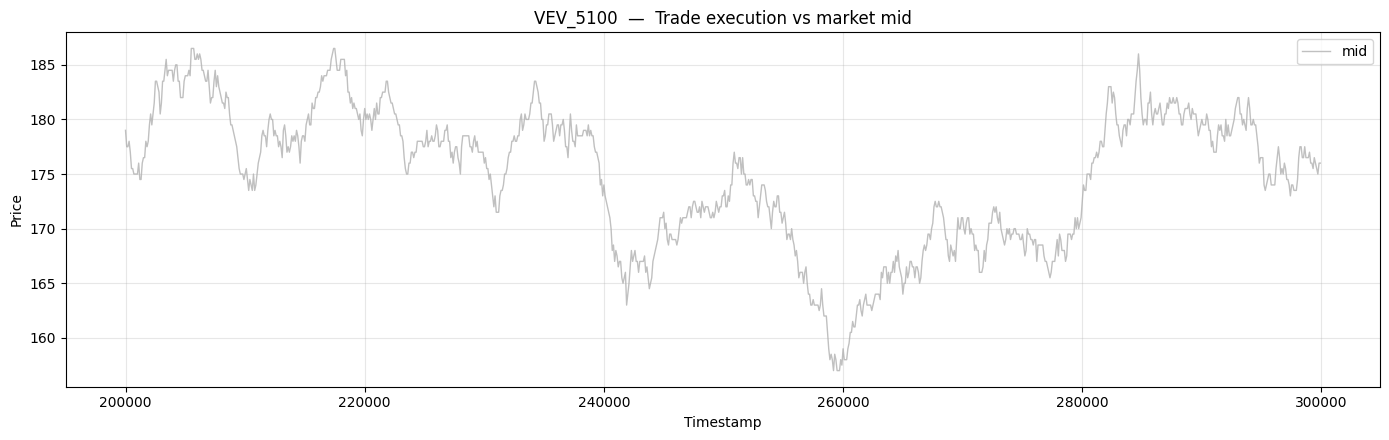

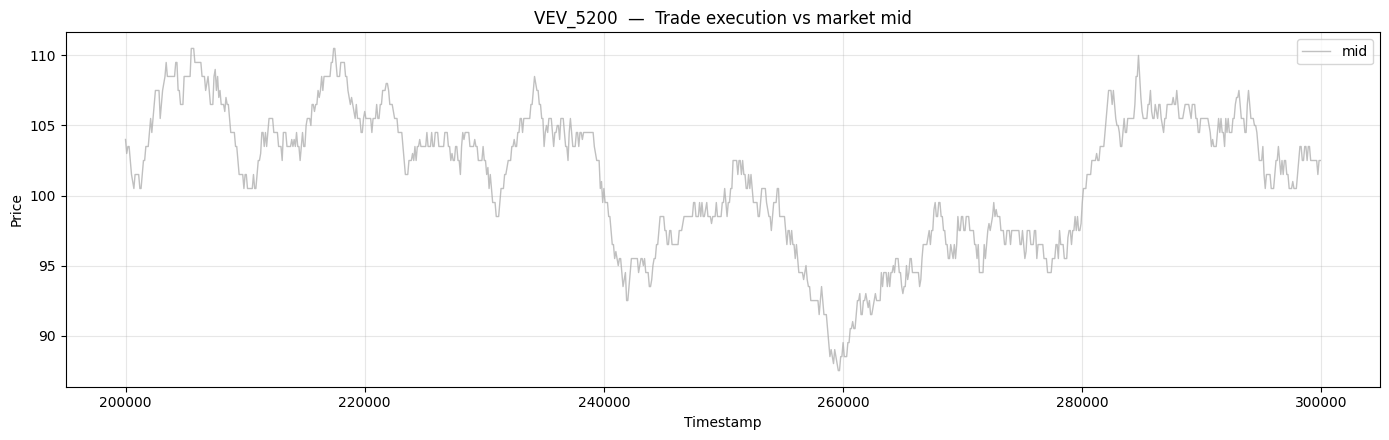

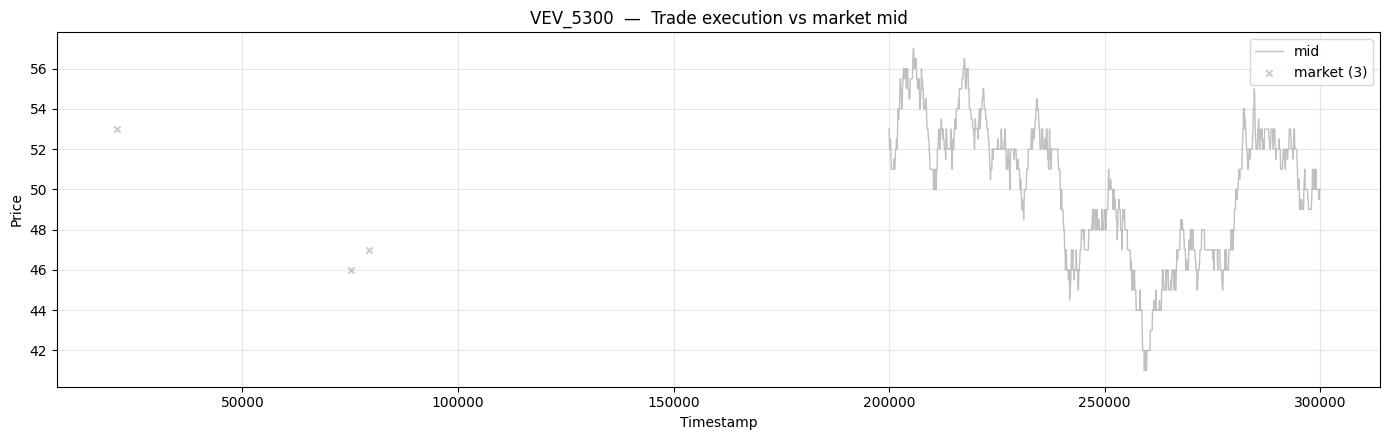

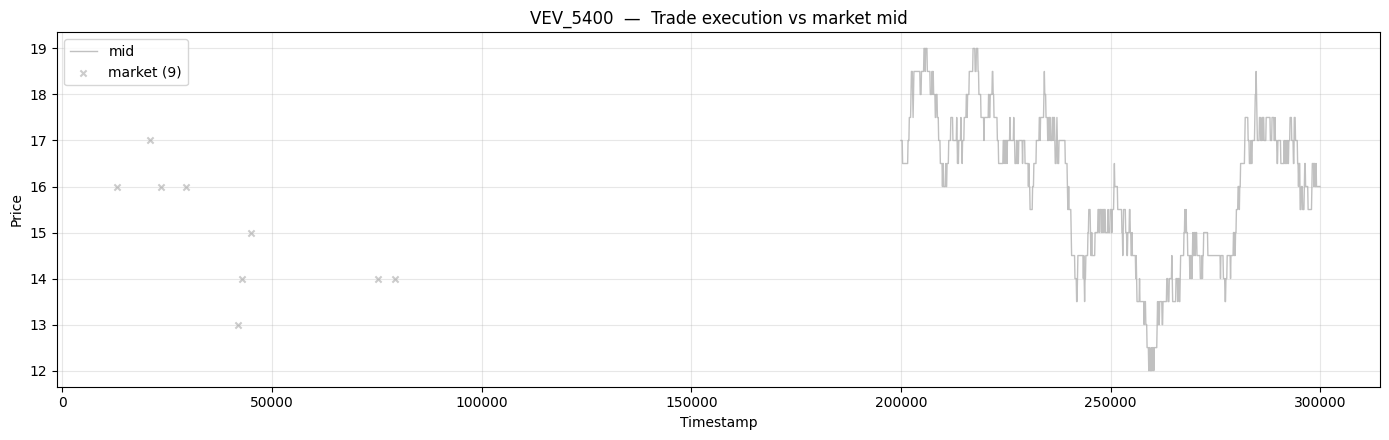

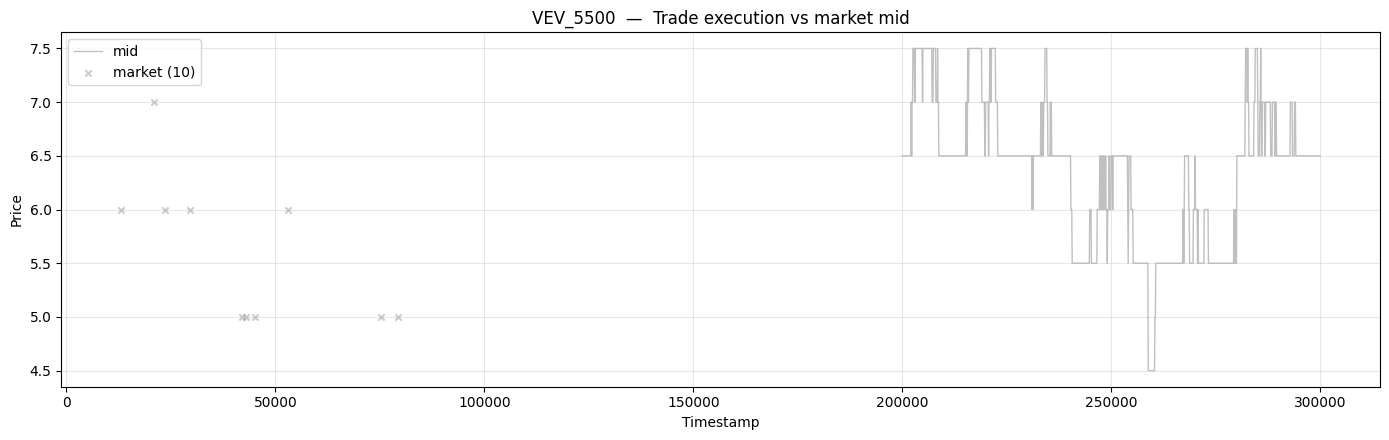

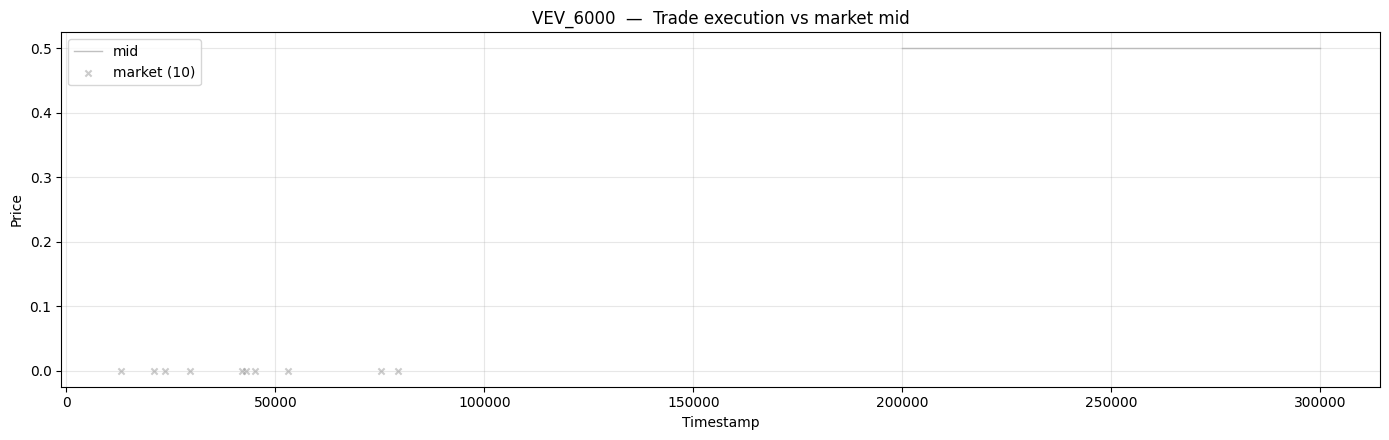

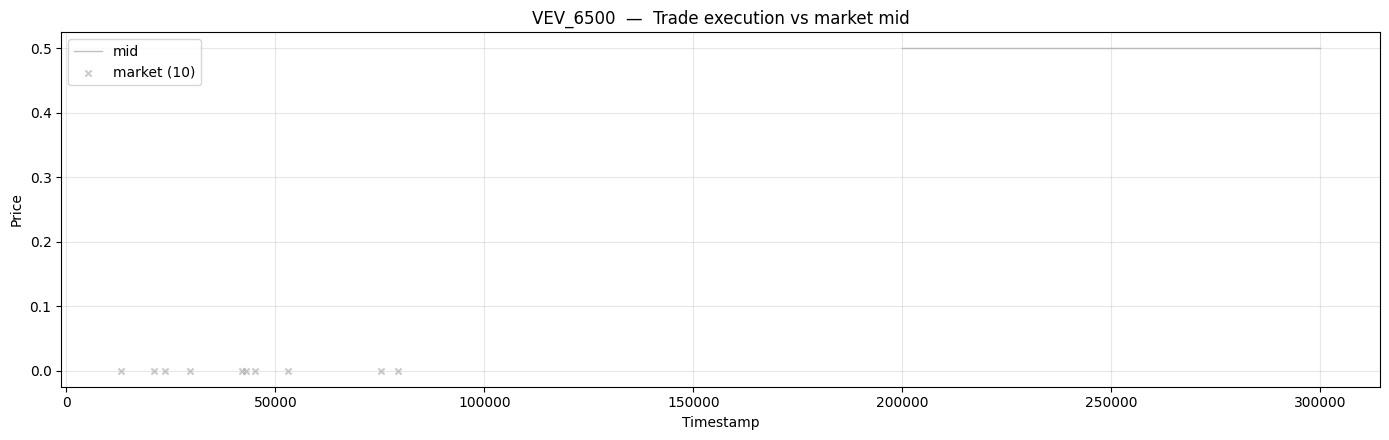

In [6]:
for product in products:
    p = acts[acts["product"] == product].copy()
    p["mid_price"] = p["mid_price"].replace(0, np.nan).ffill()
    t = trades[trades["symbol"] == product]
    buys, sells, other = t[t["side"]=="BUY"], t[t["side"]=="SELL"], t[t["side"]=="OTHER"]

    fig, ax = plt.subplots(figsize=(14, 4.5))
    ax.plot(p["global_ts"], p["mid_price"], color="silver", linewidth=1, zorder=1, label="mid")
    if len(other):
        ax.scatter(other["timestamp"], other["price"], marker="x", color="grey",
                   s=20, alpha=0.4, zorder=2, label=f"market ({len(other)})")
    if len(buys):
        ax.scatter(buys["timestamp"], buys["price"], marker="^", color="steelblue",
                   s=70, zorder=5, label=f"BUY ({len(buys)} fills, {int(buys['quantity'].sum())}u)")
    if len(sells):
        ax.scatter(sells["timestamp"], sells["price"], marker="v", color="tomato",
                   s=70, zorder=5, label=f"SELL ({len(sells)} fills, {int(sells['quantity'].sum())}u)")
    ax.set_xlabel("Timestamp"); ax.set_ylabel("Price")
    ax.set_title(f"{product}  —  Trade execution vs market mid")
    ax.legend(loc="best"); plt.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/results_03_trades_{product}.png", dpi=120, bbox_inches="tight")
    plt.show()

---
## 4. Position over time (per product)
Reconstructed from cumulative `signed_qty` of SUBMISSION fills. Red dashed = ±position-limit.

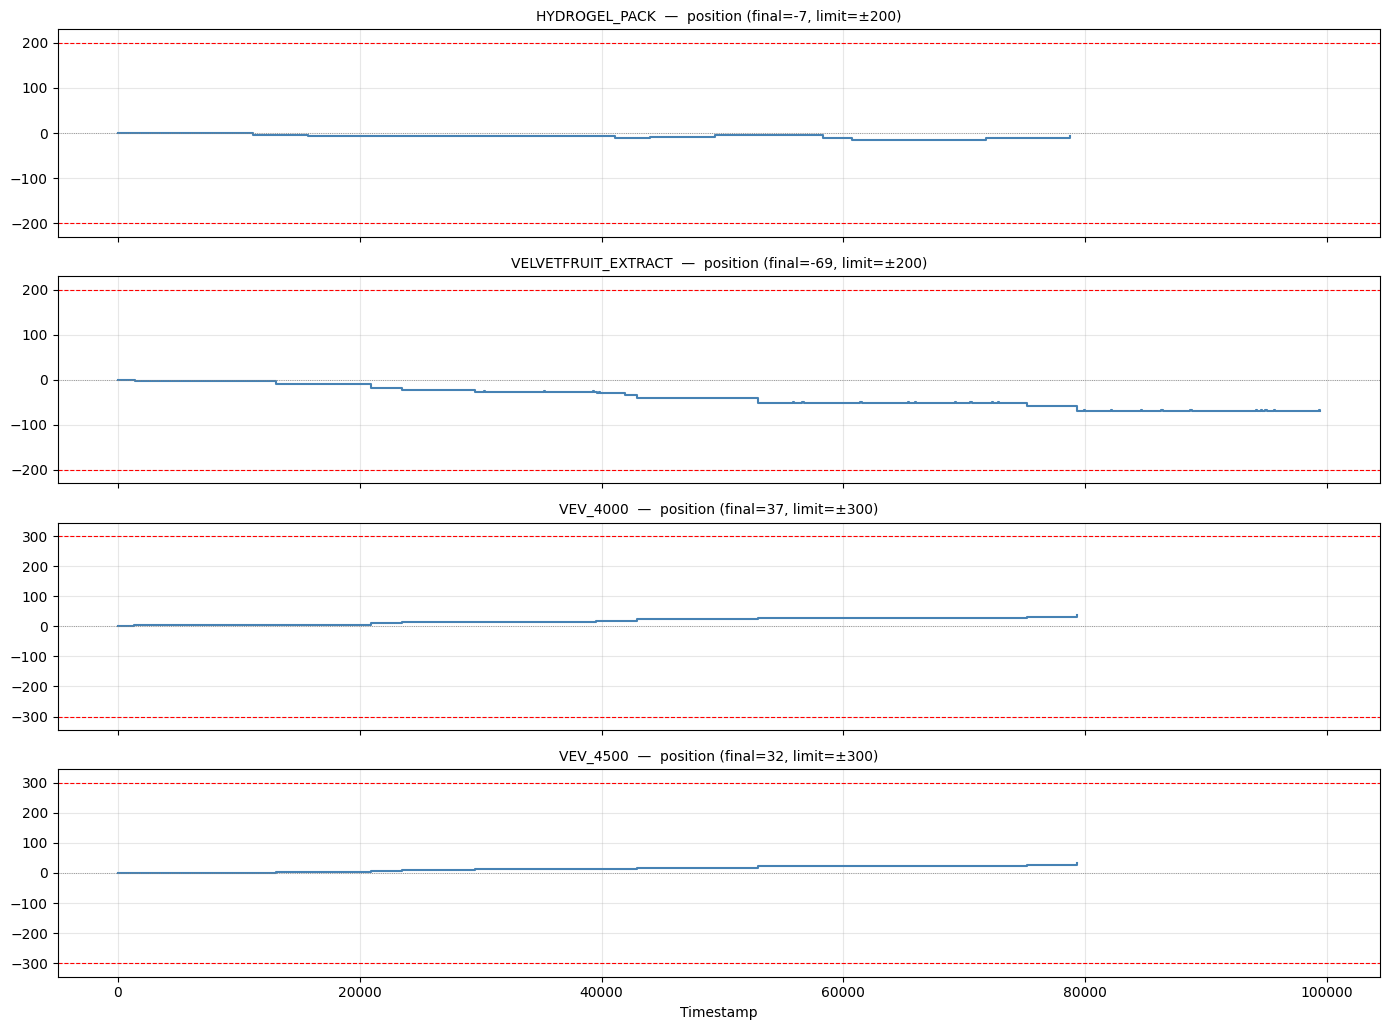

In [7]:
rows_per_fig = 3
prods_with_trades = [p for p in products if len(sub_trades[sub_trades["symbol"]==p])]
if not prods_with_trades:
    print("No SUBMISSION trades — skipping.")
else:
    fig, axes = plt.subplots(len(prods_with_trades), 1,
                             figsize=(14, 2.6*len(prods_with_trades)), sharex=True)
    if len(prods_with_trades) == 1: axes = [axes]
    for ax, product in zip(axes, prods_with_trades):
        t = sub_trades[sub_trades["symbol"]==product].sort_values("timestamp").copy()
        t["position"] = t["signed_qty"].cumsum()
        timeline = pd.concat([pd.DataFrame({"timestamp":[0],"position":[0]}),
                              t[["timestamp","position"]]], ignore_index=True)
        lim = POSITION_LIMITS.get(product, 100)
        ax.step(timeline["timestamp"], timeline["position"], where="post",
                linewidth=1.5, color="steelblue")
        ax.axhline( lim, color="red", linestyle="--", linewidth=0.8)
        ax.axhline(-lim, color="red", linestyle="--", linewidth=0.8)
        ax.axhline(0, color="grey", linewidth=0.6, linestyle=":")
        fp = final_pos.get(product, "?")
        ax.set_title(f"{product}  —  position (final={fp}, limit=±{lim})", fontsize=10)
        ax.set_ylim(-lim*1.15, lim*1.15)
    axes[-1].set_xlabel("Timestamp")
    plt.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/results_04_position.png", dpi=120, bbox_inches="tight")
    plt.show()

---
## Black-Scholes helpers (mirrors `round3/strats/trader2.py`)

In [8]:
class BlackScholes:
    @staticmethod
    def norm_cdf(x): return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))
    @staticmethod
    def norm_pdf(x): return math.exp(-0.5*x*x) / math.sqrt(2.0*math.pi)
    @staticmethod
    def _d1d2(S, K, T, sigma):
        v = sigma * math.sqrt(T)
        d1 = (math.log(S/K) + 0.5*sigma*sigma*T) / v
        return d1, d1 - v
    @staticmethod
    def call_price(S, K, T, sigma):
        if T<=0 or sigma<=0 or S<=0 or K<=0: return max(S-K, 0.0)
        d1, d2 = BlackScholes._d1d2(S, K, T, sigma)
        return S*BlackScholes.norm_cdf(d1) - K*BlackScholes.norm_cdf(d2)
    @staticmethod
    def call_delta(S, K, T, sigma):
        if T<=0 or sigma<=0: return 1.0 if S>K else (0.5 if S==K else 0.0)
        d1,_ = BlackScholes._d1d2(S, K, T, sigma)
        return BlackScholes.norm_cdf(d1)
    @staticmethod
    def implied_vol(C, S, K, T, lo=1e-4, hi=5.0, tol=1e-5, maxit=60):
        if T<=0 or S<=0 or K<=0: return None
        intrinsic = max(S-K, 0.0)
        if C < intrinsic-1e-6 or C > S+1e-6 or C <= intrinsic+1e-6: return None
        f_lo = BlackScholes.call_price(S,K,T,lo) - C
        f_hi = BlackScholes.call_price(S,K,T,hi) - C
        if f_lo*f_hi > 0: return None
        for _ in range(maxit):
            mid = 0.5*(lo+hi)
            f_mid = BlackScholes.call_price(S,K,T,mid) - C
            if abs(f_mid) < tol: return mid
            if f_lo*f_mid < 0: hi, f_hi = mid, f_mid
            else:              lo, f_lo = mid, f_mid
        return 0.5*(lo+hi)

# ── Build a per-tick (timestamp, S, T) table indexed by global_ts ─────
vee = (acts[acts["product"]==UNDERLYING][["day","timestamp","mid_price"]]
       .copy().sort_values(["day","timestamp"]).reset_index(drop=True))
vee["mid_price"] = vee["mid_price"].replace(0, np.nan).ffill()
# day_offset = number of completed days before this row
vee["day_offset"] = vee["day"] - vee["day"].min()
vee["tte_days"]   = (TTE_DAYS_AT_ROUND_START - vee["day_offset"]
                     - vee["timestamp"]/TICKS_PER_DAY).clip(lower=1e-6)
vee["T"]          = vee["tte_days"] / TRADING_DAYS_PER_YEAR
vee["S"]          = vee["mid_price"]
S_T = vee.set_index(["day","timestamp"])[["S","T","tte_days"]]
print(f"Underlying ticks: {len(vee)}, S range [{vee['S'].min():.1f}, {vee['S'].max():.1f}],",
      f"TTE [{vee['tte_days'].min():.4f}, {vee['tte_days'].max():.4f}] days")

Underlying ticks: 1000, S range [5241.5, 5276.5], TTE [4.9001, 5.0000] days


---
## 5. Trade quality (edge vs reference fair)
For HYDROGEL we compare against trader2's static fair (9990). For vouchers we use the
**reconstructed BS fair** at each fill timestamp, using the live (or last-good) IV from §8.
This section runs AFTER IV reconstruction (§8) and writes its outputs there. We keep a
quick volume-bar here.

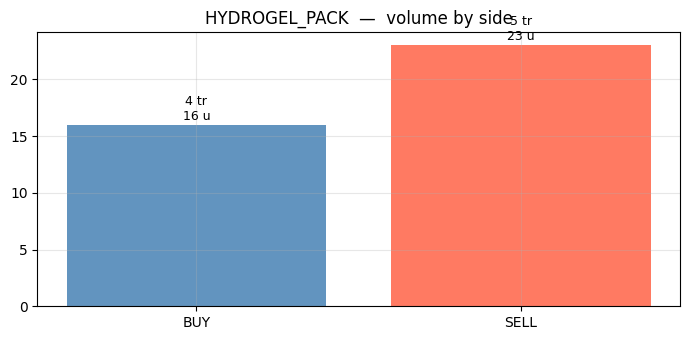

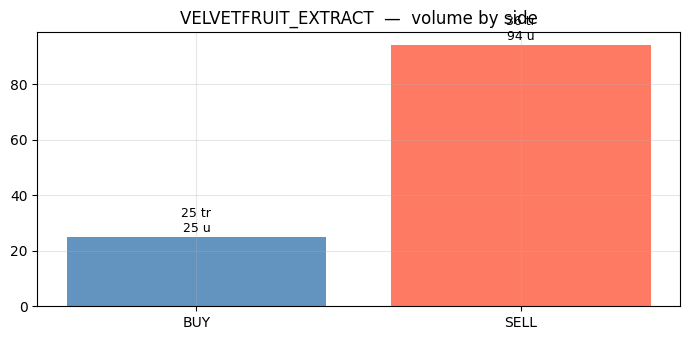

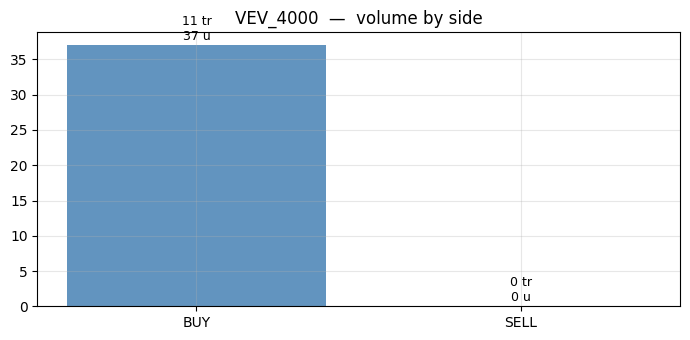

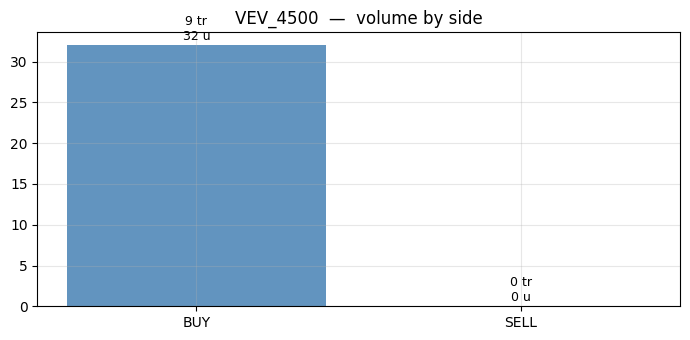

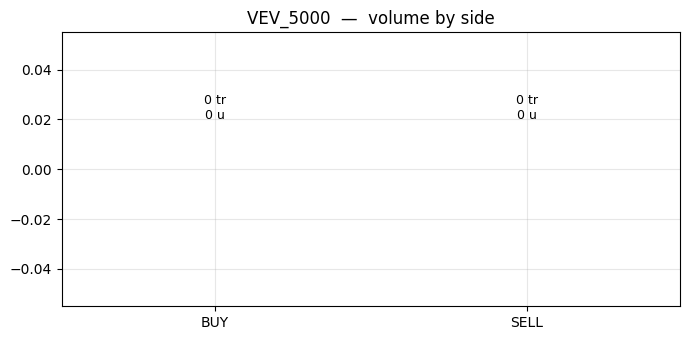

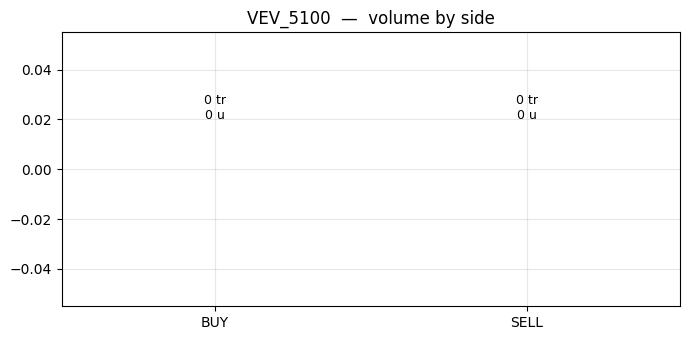

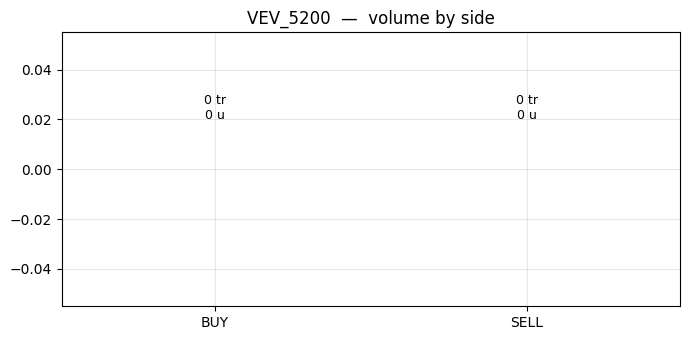

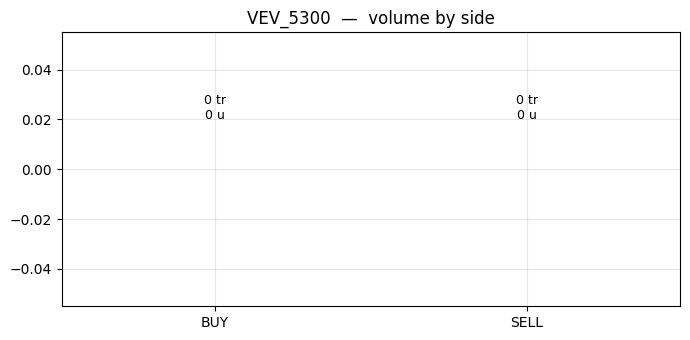

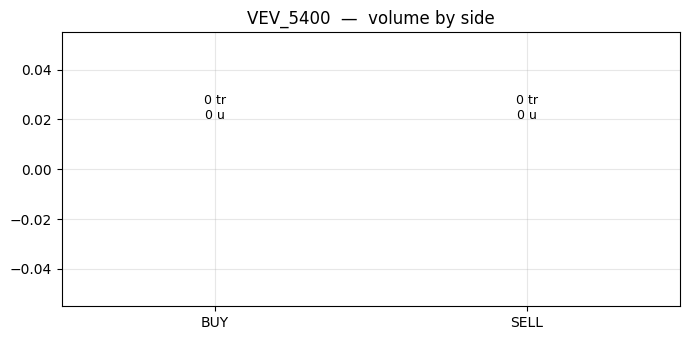

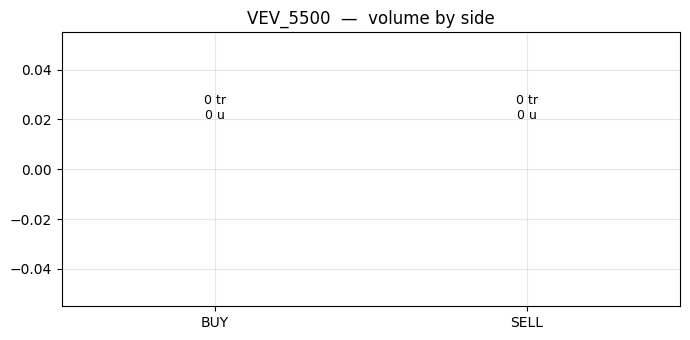

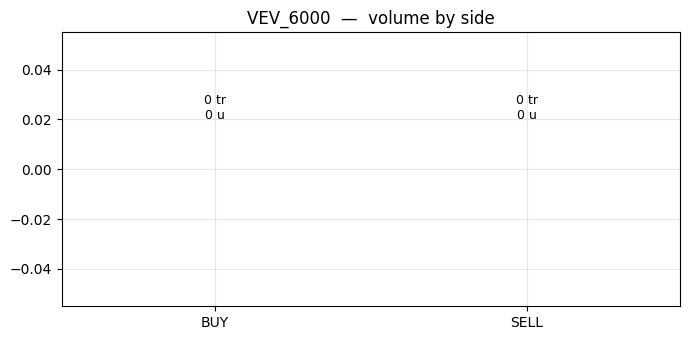

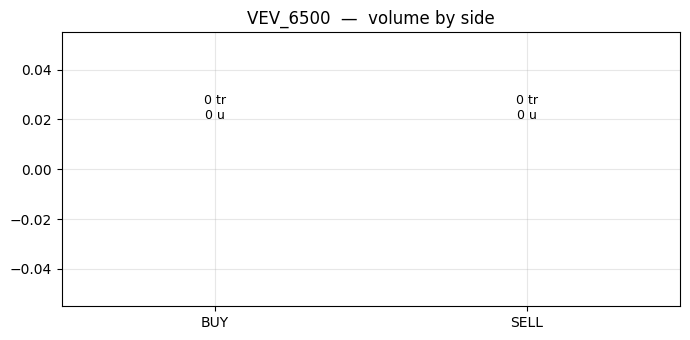

In [9]:
edge_lines = []
for product in products:
    t = sub_trades[sub_trades["symbol"]==product]
    buys, sells = t[t["side"]=="BUY"], t[t["side"]=="SELL"]
    fig, ax = plt.subplots(figsize=(7, 3.5))
    sides = ["BUY","SELL"]; vols = [int(buys["quantity"].sum()), int(sells["quantity"].sum())]
    cnts  = [len(buys), len(sells)]
    bars = ax.bar(sides, vols, color=["steelblue","tomato"], alpha=0.85)
    for b, v, c in zip(bars, vols, cnts):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+max(max(vols),1)*0.02,
                f"{c} tr\n{v} u", ha="center", fontsize=9)
    ax.set_title(f"{product}  —  volume by side")
    plt.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/results_05_quality_{product}.png", dpi=110, bbox_inches="tight")
    plt.show()
    edge_lines.append(f"{product}: BUY {cnts[0]} tr / {vols[0]} u | SELL {cnts[1]} tr / {vols[1]} u")
with open(f"{OUTPUT_DIR}/results_05_edge_stats.txt", "w") as f:
    f.write("\n".join(edge_lines) + "\n")

---
## 6. Per-product PnL breakdown + summary table

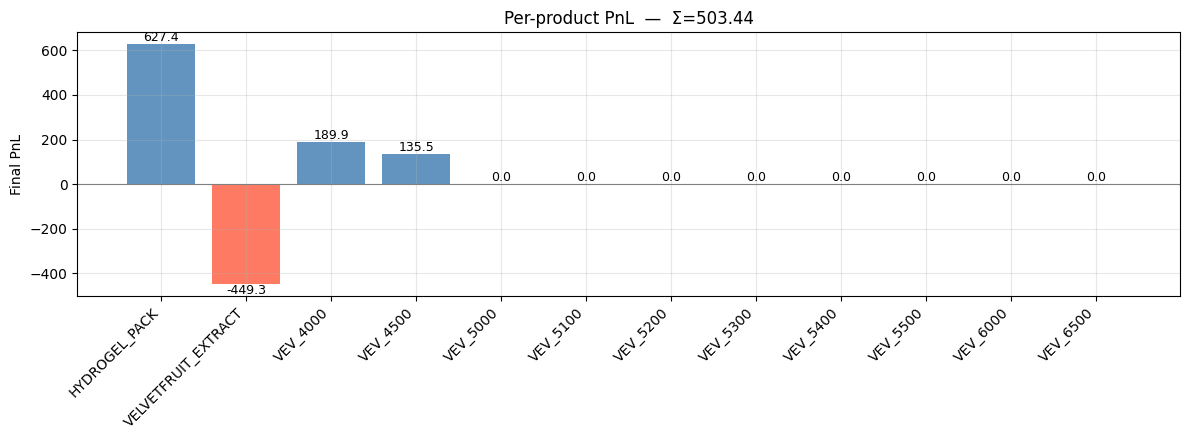

,trades,buy_vol,sell_vol,avg_buy_px,avg_sell_px,final_pos,final_pnl
product,,,,,,,
HYDROGEL_PACK,9,16,23,9963.50,9998.80,-7.0,627.41
VELVETFRUIT_EXTRACT,61,25,94,5261.32,5258.69,-69.0,-449.31
VEV_4000,11,37,0,1258.64,NaN,37.0,189.86
VEV_4500,9,32,0,759.78,NaN,32.0,135.48
VEV_5000,0,0,0,NaN,NaN,NaN,0.00
VEV_5100,0,0,0,NaN,NaN,NaN,0.00
VEV_5200,0,0,0,NaN,NaN,NaN,0.00
VEV_5300,0,0,0,NaN,NaN,NaN,0.00
VEV_5400,0,0,0,NaN,NaN,NaN,0.00


In [10]:
product_pnl = {p: acts[acts["product"]==p]["profit_and_loss"].iloc[-1] for p in products}
order = [HYDROGEL, UNDERLYING] + VOUCHERS
order = [p for p in order if p in product_pnl]
vals  = [product_pnl[p] for p in order]
colors = ["steelblue" if v>=0 else "tomato" for v in vals]
fig, ax = plt.subplots(figsize=(12, 4.5))
bars = ax.bar(order, vals, color=colors, alpha=0.85)
ax.axhline(0, color="grey", linewidth=0.8)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height(),
            f"{v:.1f}", ha="center", va="bottom" if v>=0 else "top", fontsize=9)
ax.set_ylabel("Final PnL"); ax.set_title(f"Per-product PnL  —  Σ={sum(vals):.2f}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/results_06_pnl_breakdown.png", dpi=130, bbox_inches="tight")
plt.show()

rows = []
for p in order:
    t = sub_trades[sub_trades["symbol"]==p]
    buys, sells = t[t["side"]=="BUY"], t[t["side"]=="SELL"]
    rows.append({
        "product": p, "trades": len(t),
        "buy_vol": int(buys["quantity"].sum()), "sell_vol": int(sells["quantity"].sum()),
        "avg_buy_px": round(buys["price"].mean(),2) if len(buys) else None,
        "avg_sell_px": round(sells["price"].mean(),2) if len(sells) else None,
        "final_pos": final_pos.get(p),
        "final_pnl": round(product_pnl[p], 2),
    })
summary = pd.DataFrame(rows).set_index("product")
summary.to_csv(f"{OUTPUT_DIR}/results_06_summary_table.csv")
display(summary)

---
## 7. Position-limit constraint analysis (per product)
Reports % of ticks at the ±position-limit. For VEE this directly measures **whether the
delta-hedger ran out of inventory budget**.

In [11]:
def position_timeline(product):
    """Per-tick position series aligned to acts['timestamp'] for `product`."""
    p = acts[acts["product"]==product][["day","timestamp"]].drop_duplicates().sort_values(["day","timestamp"])
    t = sub_trades[sub_trades["symbol"]==product].sort_values("timestamp").copy()
    if len(t)==0:
        p["position"] = 0
        return p
    t["position"] = t["signed_qty"].cumsum()
    pos_at_ts = dict(zip(t["timestamp"], t["position"]))
    cur = 0; out = []
    for ts in p["timestamp"]:
        if ts in pos_at_ts: cur = pos_at_ts[ts]
        out.append(cur)
    p["position"] = out
    return p

constraint_lines = []
for product in products:
    lim = POSITION_LIMITS.get(product, 0)
    p = position_timeline(product)
    pct_max_long  = (p["position"] >=  lim).mean() * 100
    pct_max_short = (p["position"] <= -lim).mean() * 100
    line = f"{product:24s}  lim=±{lim:<3}  long-cap={pct_max_long:5.1f}%  short-cap={pct_max_short:5.1f}%"
    print(line); constraint_lines.append(line)
with open(f"{OUTPUT_DIR}/results_07_constraint_analysis.txt", "w") as f:
    f.write("\n".join(constraint_lines) + "\n")

HYDROGEL_PACK             lim=±200  long-cap=  0.0%  short-cap=  0.0%
VELVETFRUIT_EXTRACT       lim=±200  long-cap=  0.0%  short-cap=  0.0%
VEV_4000                  lim=±300  long-cap=  0.0%  short-cap=  0.0%
VEV_4500                  lim=±300  long-cap=  0.0%  short-cap=  0.0%
VEV_5000                  lim=±300  long-cap=  0.0%  short-cap=  0.0%
VEV_5100                  lim=±300  long-cap=  0.0%  short-cap=  0.0%
VEV_5200                  lim=±300  long-cap=  0.0%  short-cap=  0.0%
VEV_5300                  lim=±300  long-cap=  0.0%  short-cap=  0.0%
VEV_5400                  lim=±300  long-cap=  0.0%  short-cap=  0.0%
VEV_5500                  lim=±300  long-cap=  0.0%  short-cap=  0.0%
VEV_6000                  lim=±300  long-cap=  0.0%  short-cap=  0.0%
VEV_6500                  lim=±300  long-cap=  0.0%  short-cap=  0.0%


---
## 8. IV reconstruction per voucher
Inverts BS implied vol from each voucher's mid against VEE's mid + per-tick TTE.
The `live_iv is None` rate matches trader2's BS-fallback path frequency.

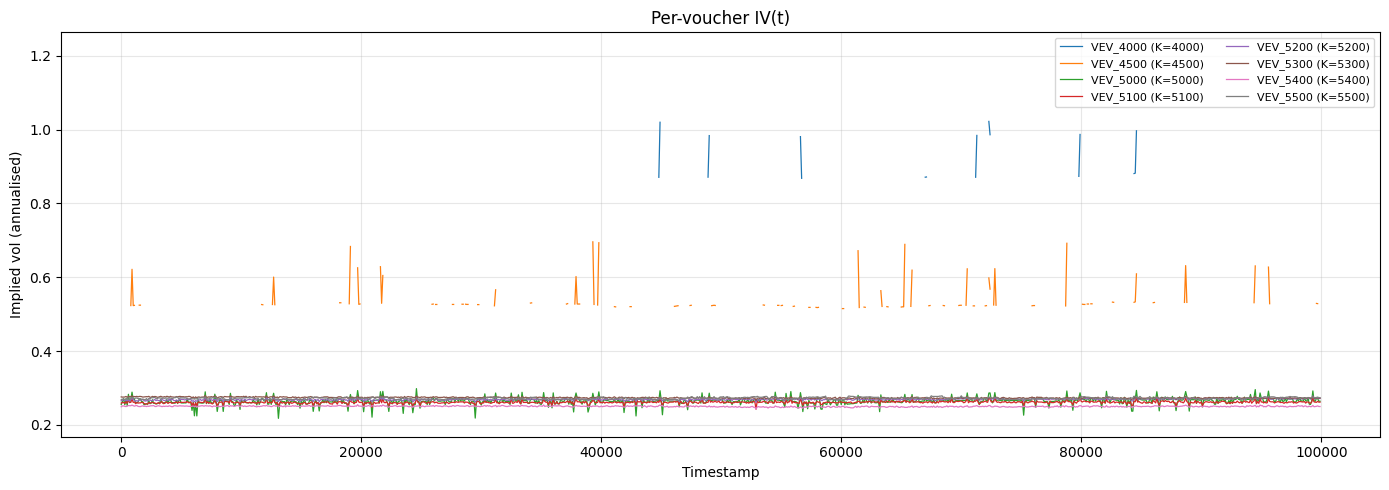

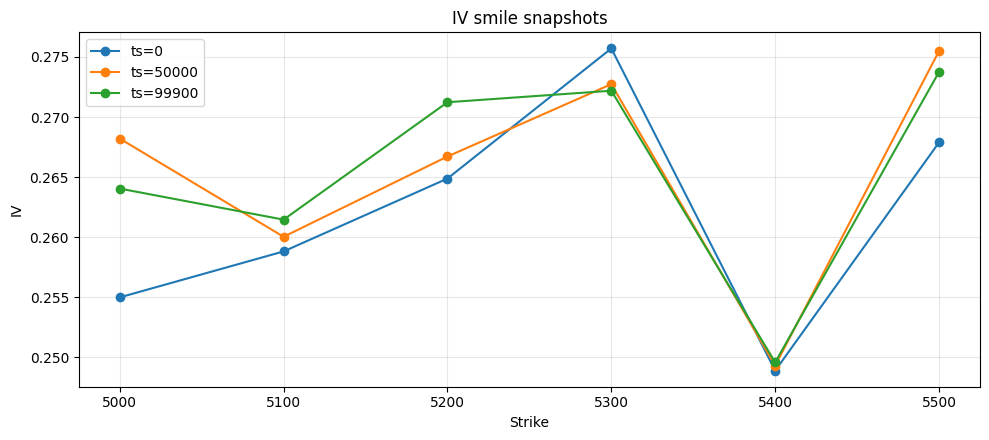

voucher        K     iv_mean  iv_std   inv_fail%
VEV_4000    4000   0.9685  0.0978    91.6
VEV_4500    4500   0.5420  0.0413    71.3
VEV_5000    5000   0.2644  0.0093     0.1
VEV_5100    5100   0.2610  0.0034     0.0
VEV_5200    5200   0.2689  0.0022     0.0
VEV_5300    5300   0.2736  0.0017     0.0
VEV_5400    5400   0.2500  0.0014     0.0
VEV_5500    5500   0.2718  0.0025     0.0


In [12]:
# Build wide tables: voucher mids per timestamp aligned to underlying ticks.
und_keys = vee[["day","timestamp"]].copy()

iv_table   = {}
mid_table  = {}
inv_failed = {}
for v in TRADED_VOUCHERS:
    df = (acts[acts["product"]==v][["day","timestamp","mid_price"]]
          .replace({"mid_price":{0: np.nan}})
          .merge(und_keys, on=["day","timestamp"], how="right")
          .sort_values(["day","timestamp"])
          .reset_index(drop=True))
    df["mid_price"] = df["mid_price"].ffill()
    K = VOUCHER_STRIKE[v]
    ivs = []; fail = 0
    for s, t, c in zip(vee["S"], vee["T"], df["mid_price"]):
        if pd.isna(c) or pd.isna(s):
            ivs.append(np.nan); fail += 1; continue
        iv = BlackScholes.implied_vol(c, s, K, t)
        if iv is None: fail += 1
        ivs.append(iv if iv is not None else np.nan)
    iv_table[v]  = ivs
    mid_table[v] = df["mid_price"].values
    inv_failed[v] = fail

iv_df  = pd.DataFrame(iv_table,  index=vee["timestamp"].values)
mid_df = pd.DataFrame(mid_table, index=vee["timestamp"].values)

# IV time series
fig, ax = plt.subplots(figsize=(14, 5))
for v in TRADED_VOUCHERS:
    ax.plot(iv_df.index, iv_df[v], linewidth=0.9, label=f"{v} (K={VOUCHER_STRIKE[v]})")
ax.set_xlabel("Timestamp"); ax.set_ylabel("Implied vol (annualised)")
ax.set_title("Per-voucher IV(t)"); ax.legend(loc="best", fontsize=8, ncol=2)
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/results_08_iv_timeseries.png", dpi=130, bbox_inches="tight")
plt.show()

# Smile snapshots
snaps = [iv_df.index[0], iv_df.index[len(iv_df)//2], iv_df.index[-1]]
fig, ax = plt.subplots(figsize=(10, 4.5))
for ts in snaps:
    Ks = [VOUCHER_STRIKE[v] for v in TRADED_VOUCHERS]
    ys = [iv_df.loc[ts, v] for v in TRADED_VOUCHERS]
    ax.plot(Ks, ys, marker="o", label=f"ts={ts}")
ax.set_xlabel("Strike"); ax.set_ylabel("IV"); ax.set_title("IV smile snapshots")
ax.legend(); plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/results_08_iv_smile_snapshots.png", dpi=130, bbox_inches="tight")
plt.show()

# Stats
lines = ["voucher        K     iv_mean  iv_std   inv_fail%"]
for v in TRADED_VOUCHERS:
    s = iv_df[v]
    lines.append(f"{v:10s} {VOUCHER_STRIKE[v]:5d}  {s.mean():7.4f} {s.std():7.4f}   "
                 f"{100*inv_failed[v]/len(vee):5.1f}")
txt = "\n".join(lines)
print(txt)
with open(f"{OUTPUT_DIR}/results_08_iv_stats.txt", "w") as f: f.write(txt + "\n")

---
## 9. BS delta per voucher and aggregate option delta
Uses the IV-EMA (`α=0.1`) to mirror `trader2.OptionTrader.iv_used`. Per-voucher delta
is multiplied by the reconstructed position to get per-voucher delta exposure;
DEAD vouchers are excluded from the aggregate (matches trader2).

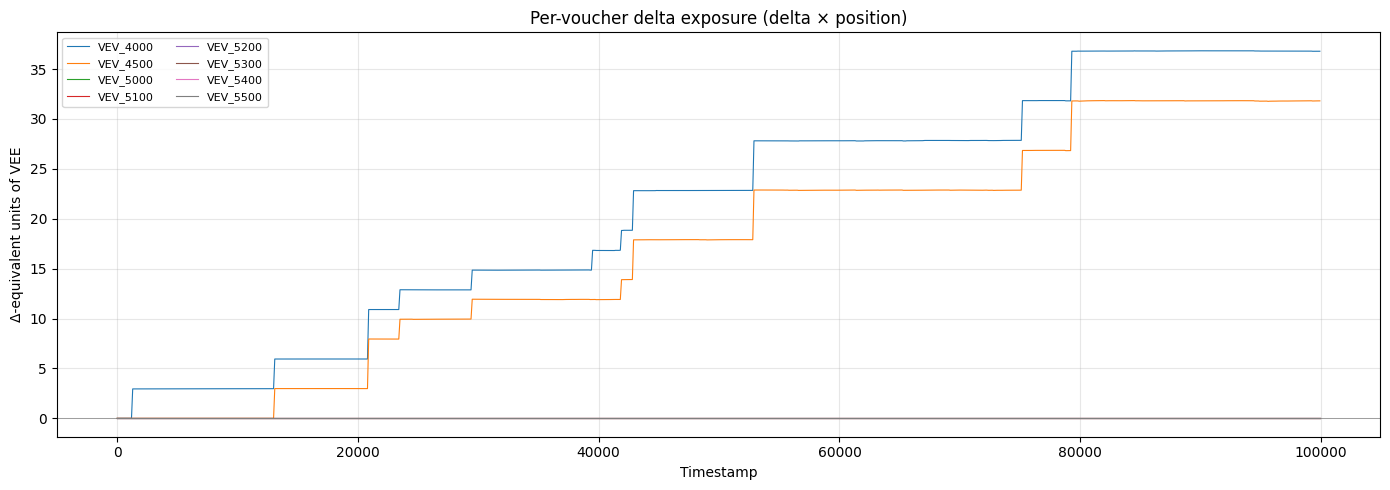

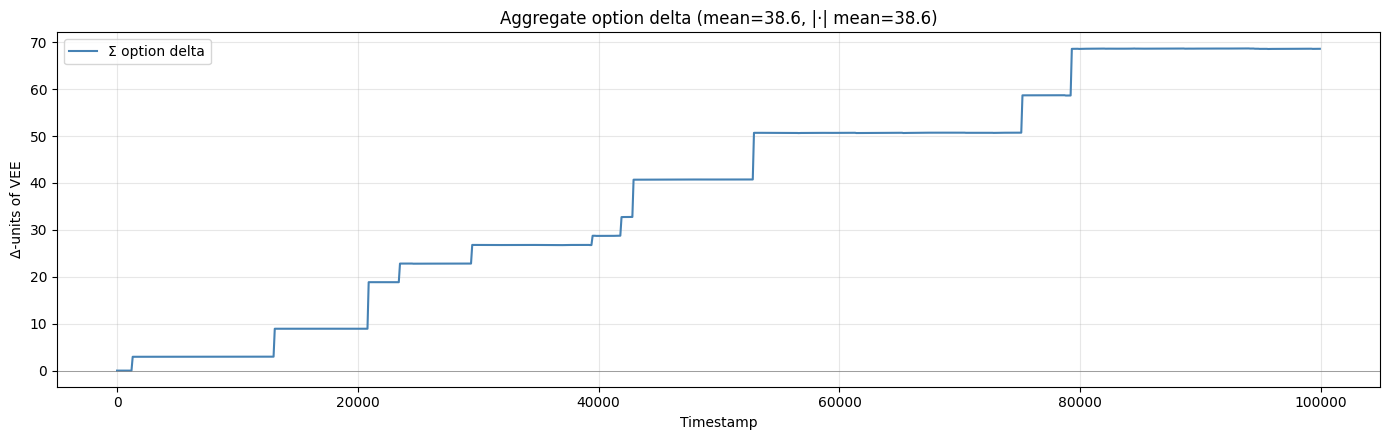

In [13]:
# Build IV EMA per voucher (ffill across NaN, EMA when value present)
iv_ema_df = pd.DataFrame(index=iv_df.index)
for v in TRADED_VOUCHERS:
    s = iv_df[v]
    ema_vals = []; ema = None
    for x in s:
        if pd.isna(x):
            ema_vals.append(ema)
        else:
            ema = x if ema is None else IV_EMA_ALPHA*x + (1-IV_EMA_ALPHA)*ema
            ema_vals.append(ema)
    iv_ema_df[v] = ema_vals
DEFAULT_IV = 0.23
iv_used = iv_ema_df.fillna(DEFAULT_IV)

# Per-voucher delta
delta_df = pd.DataFrame(index=iv_df.index)
for v in TRADED_VOUCHERS:
    K = VOUCHER_STRIKE[v]
    deltas = [BlackScholes.call_delta(s, K, T, sig) if not pd.isna(s) else 0.0
              for s, T, sig in zip(vee["S"], vee["T"], iv_used[v])]
    delta_df[v] = deltas

# Per-voucher position aligned to underlying ticks
pos_df = pd.DataFrame(index=iv_df.index)
for v in VOUCHERS + [UNDERLYING, HYDROGEL]:
    t = sub_trades[sub_trades["symbol"]==v].sort_values("timestamp").copy()
    if len(t):
        t["position"] = t["signed_qty"].cumsum()
        pos_at = dict(zip(t["timestamp"], t["position"]))
    else:
        pos_at = {}
    cur = 0; out = []
    for ts in iv_df.index:
        if ts in pos_at: cur = pos_at[ts]
        out.append(cur)
    pos_df[v] = out

# Per-voucher delta EXPOSURE = delta * position
expo_df = pd.DataFrame({v: delta_df[v] * pos_df[v] for v in TRADED_VOUCHERS},
                      index=iv_df.index)
agg_opt_delta = expo_df.sum(axis=1)
vee_pos = pos_df[UNDERLYING]
residual = agg_opt_delta + vee_pos   # full VEE position is the hedge

# Plot per-voucher delta exposure
fig, ax = plt.subplots(figsize=(14, 5))
for v in TRADED_VOUCHERS:
    ax.plot(expo_df.index, expo_df[v], linewidth=0.8, label=v)
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("Timestamp"); ax.set_ylabel("Δ-equivalent units of VEE")
ax.set_title("Per-voucher delta exposure (delta × position)")
ax.legend(ncol=2, fontsize=8); plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/results_09_voucher_delta_per_strike.png", dpi=130, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(agg_opt_delta.index, agg_opt_delta, color="steelblue", label="Σ option delta")
ax.set_xlabel("Timestamp"); ax.set_ylabel("Δ-units of VEE")
ax.set_title(f"Aggregate option delta (mean={agg_opt_delta.mean():.1f},"
             f" |·| mean={agg_opt_delta.abs().mean():.1f})")
ax.axhline(0, color="grey", linewidth=0.5); ax.legend(); plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/results_09_aggregate_option_delta.png", dpi=130, bbox_inches="tight")
plt.show()

---
## 10. Delta-hedge quality (the headline)
Three-panel: aggregate option delta, VEE position (the hedge), and **residual**. A perfect
hedge keeps residual ≈ 0. Stats: |residual| mean/p50/p95/max, % of ticks above
trader2's `delta_threshold=5`, and rehedge frequency.

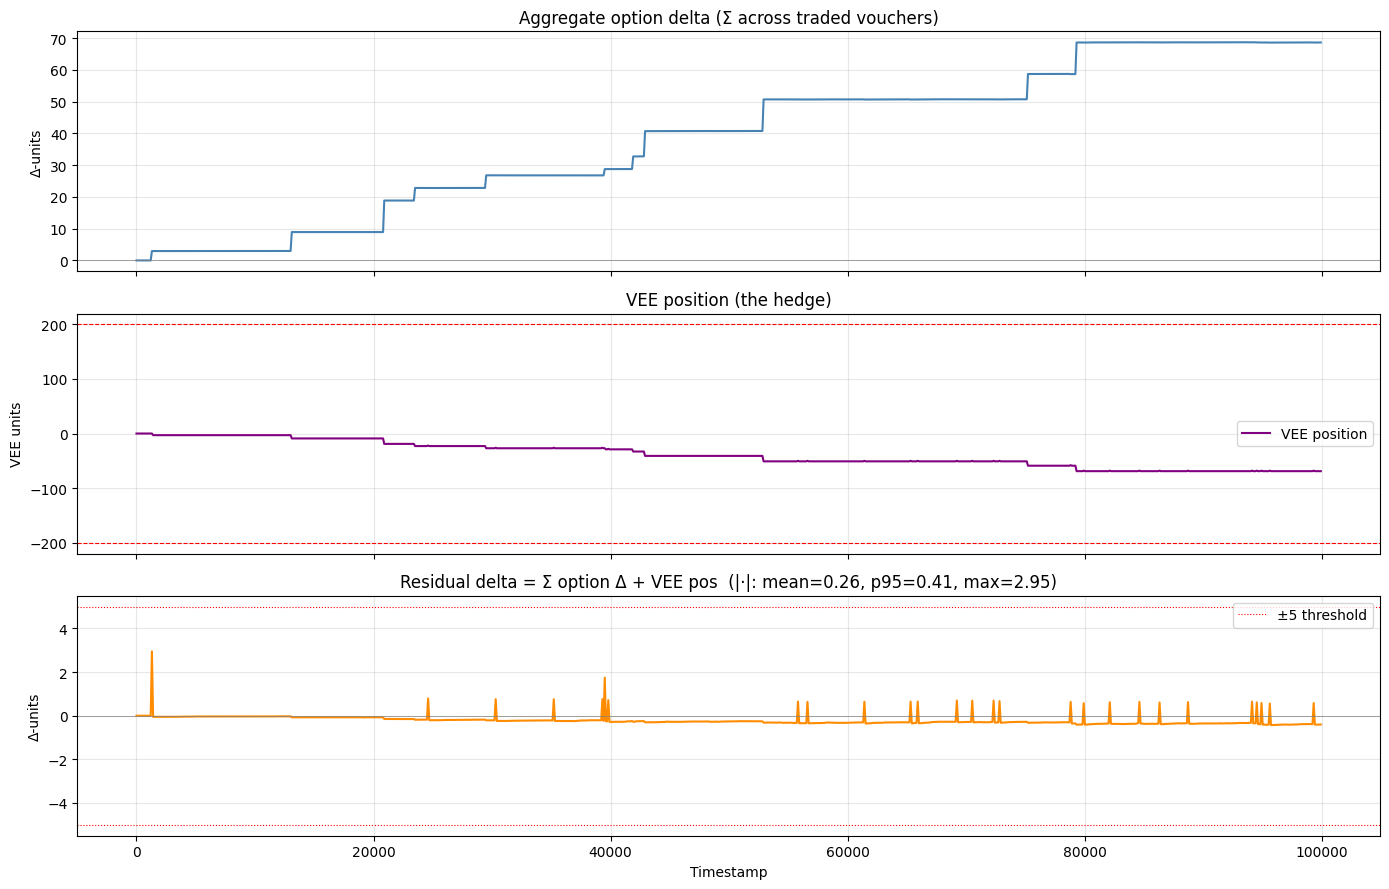

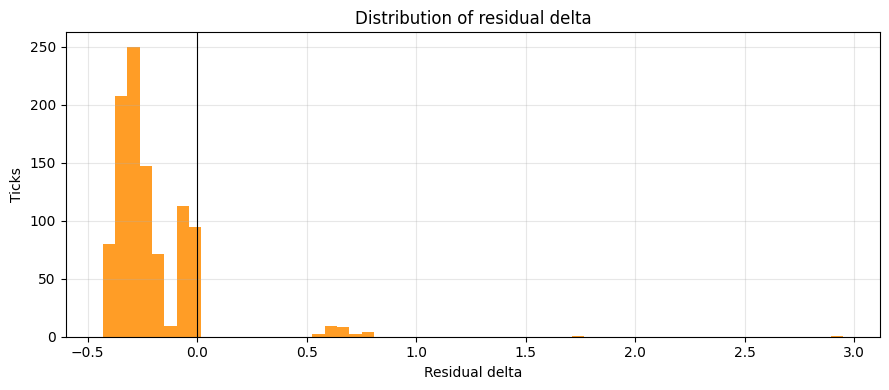

residual |delta|  mean = 0.256
residual |delta|  p50  = 0.279
residual |delta|  p95  = 0.408
residual |delta|  max  = 2.949
% ticks |residual| > 5: 0.00
% ticks |residual| > 20: 0.00
VEE rehedges (ΔVEE_pos != 0): 61  (6.10% of ticks)
% ticks at +VEE limit (200): 0.00
% ticks at -VEE limit: 0.00


In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(agg_opt_delta.index, agg_opt_delta, color="steelblue")
axes[0].axhline(0, color="grey", linewidth=0.5)
axes[0].set_title("Aggregate option delta (Σ across traded vouchers)")
axes[0].set_ylabel("Δ-units")

axes[1].plot(vee_pos.index, vee_pos, color="purple", label="VEE position")
axes[1].axhline( POSITION_LIMITS[UNDERLYING], color="red", linestyle="--", linewidth=0.8)
axes[1].axhline(-POSITION_LIMITS[UNDERLYING], color="red", linestyle="--", linewidth=0.8)
axes[1].set_title("VEE position (the hedge)"); axes[1].set_ylabel("VEE units"); axes[1].legend()

axes[2].plot(residual.index, residual, color="darkorange")
axes[2].axhline( TRADER2_DELTA_THRESHOLD, color="red", linestyle=":", linewidth=0.8,
                 label=f"±{TRADER2_DELTA_THRESHOLD} threshold")
axes[2].axhline(-TRADER2_DELTA_THRESHOLD, color="red", linestyle=":", linewidth=0.8)
axes[2].axhline(0, color="grey", linewidth=0.5)
axes[2].set_title(f"Residual delta = Σ option Δ + VEE pos  "
                  f"(|·|: mean={residual.abs().mean():.2f}, p95={residual.abs().quantile(0.95):.2f},"
                  f" max={residual.abs().max():.2f})")
axes[2].set_ylabel("Δ-units"); axes[2].set_xlabel("Timestamp"); axes[2].legend()
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/results_10_delta_hedge_overlay.png", dpi=130, bbox_inches="tight")
plt.show()

# Residual histogram
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(residual.dropna(), bins=60, color="darkorange", alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Residual delta"); ax.set_ylabel("Ticks")
ax.set_title("Distribution of residual delta")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/results_10_residual_hist.png", dpi=130, bbox_inches="tight")
plt.show()

# Stats
abs_r = residual.abs()
nticks = len(residual)
rehedge_count = int((vee_pos.diff().fillna(0) != 0).sum())
hedge_quality = [
    f"residual |delta|  mean = {abs_r.mean():.3f}",
    f"residual |delta|  p50  = {abs_r.median():.3f}",
    f"residual |delta|  p95  = {abs_r.quantile(0.95):.3f}",
    f"residual |delta|  max  = {abs_r.max():.3f}",
    f"% ticks |residual| > {TRADER2_DELTA_THRESHOLD}: {100*(abs_r>TRADER2_DELTA_THRESHOLD).mean():.2f}",
    f"% ticks |residual| > 20: {100*(abs_r>20).mean():.2f}",
    f"VEE rehedges (ΔVEE_pos != 0): {rehedge_count}  ({100*rehedge_count/max(nticks,1):.2f}% of ticks)",
    f"% ticks at +VEE limit ({POSITION_LIMITS[UNDERLYING]}): {100*(vee_pos>=POSITION_LIMITS[UNDERLYING]).mean():.2f}",
    f"% ticks at -VEE limit: {100*(vee_pos<=-POSITION_LIMITS[UNDERLYING]).mean():.2f}",
]
txt = "\n".join(hedge_quality); print(txt)
with open(f"{OUTPUT_DIR}/results_10_hedge_quality.txt", "w") as f: f.write(txt + "\n")

---
## 11. Counterfactual hedge policies
Replays the realised aggregate-option-delta path under alternative VEE-hedge rules and
computes a **delta-PnL proxy**: `Σ residual(t) · ΔS(t+1)` (positive = hedge profited from
the move, negative = unhedged exposure cost money). VEE position capped at ±200.

Policies compared:
- **A** trader2 (rehedge each tick OR |Δ|>5)
- **B** every-tick perfect hedge
- **C** threshold-only at {10, 20, 40}
- **D** periodic at {100, 500, 2000} ts
- **E** no hedging baseline

> Notes on alternatives that this notebook does not simulate but recommends:
> - **Vega/skew hedging** by trading two vouchers against each other (long one strike,
>   short another) to reduce sensitivity to IV moves — the residual variance in §10 that
>   isn't explained by VEE moves is mostly vega.
> - **Gamma-aware delta band** widening the threshold when |gamma·ΔS| is small.

,rehedges,delta_pnl
policy,,
A trader2 (every+|Δ|>5),11,-1.79
B every-tick perfect,11,-1.79
C threshold |Δ|>10,4,-19.29
C threshold |Δ|>20,2,133.21
C threshold |Δ|>40,1,-213.29
D periodic 100 ts,11,-1.79
D periodic 500 ts,11,-1.79
D periodic 2000 ts,11,-25.79
E no hedge,0,217.21


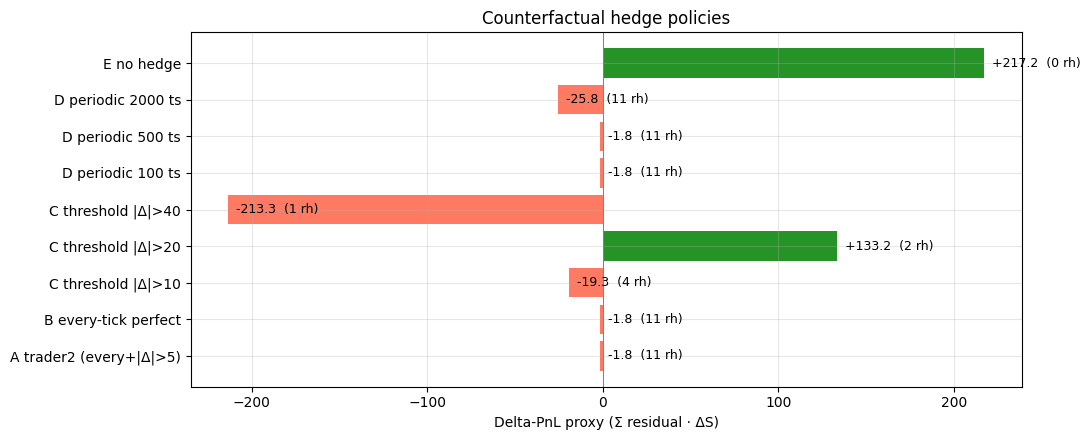

In [15]:
S_series   = vee["S"].reset_index(drop=True)
agg_series = agg_opt_delta.reset_index(drop=True)
dS         = S_series.diff().shift(-1).fillna(0.0)   # ΔS(t+1)
LIM        = POSITION_LIMITS[UNDERLYING]

def simulate(policy_fn):
    """policy_fn(t, opt_delta_t, current_vee_pos, last_hedge_t) -> new_vee_pos.
    Returns (vee_pos_series, residual_series, rehedge_count, delta_pnl)."""
    n = len(agg_series)
    vee_pos = np.zeros(n); residual = np.zeros(n)
    last_h = -10**9
    rehedges = 0
    cur = 0
    for i in range(n):
        new_pos = policy_fn(i, agg_series.iat[i], cur, last_h)
        new_pos = max(-LIM, min(LIM, int(round(new_pos))))
        if new_pos != cur:
            rehedges += 1; last_h = i
        cur = new_pos
        vee_pos[i] = cur
        residual[i] = agg_series.iat[i] + cur
    pnl = float((residual * dS.values).sum())
    return vee_pos, residual, rehedges, pnl

# Policies
def pol_A(i, d, cur, last):     # trader2: every tick OR |Δ trade|>5
    target = -d
    delta_trade = int(round(target)) - cur
    if (i - last) >= TRADER2_HEDGE_EVERY_TICKS or abs(delta_trade) > TRADER2_DELTA_THRESHOLD:
        return target
    return cur
def pol_B(i, d, cur, last):  return -d
def pol_C(thresh):
    def f(i, d, cur, last):
        target = -d
        return target if abs(target - cur) > thresh else cur
    return f
def pol_D(period):
    def f(i, d, cur, last):
        return -d if (last < 0 or (i - last) >= period) else cur
    return f
def pol_E(i, d, cur, last):  return 0

policies = [
    ("A trader2 (every+|Δ|>5)", pol_A),
    ("B every-tick perfect",     pol_B),
    ("C threshold |Δ|>10",       pol_C(10)),
    ("C threshold |Δ|>20",       pol_C(20)),
    ("C threshold |Δ|>40",       pol_C(40)),
    ("D periodic 100 ts",        pol_D(1)),     # 1 underlying-tick = 100 ts
    ("D periodic 500 ts",        pol_D(5)),
    ("D periodic 2000 ts",       pol_D(20)),
    ("E no hedge",               pol_E),
]
rows = []
for name, fn in policies:
    _, _, rh, pnl = simulate(fn)
    rows.append({"policy": name, "rehedges": rh, "delta_pnl": round(pnl, 2)})
ctf = pd.DataFrame(rows).set_index("policy")
display(ctf)
ctf.to_csv(f"{OUTPUT_DIR}/results_11_hedge_counterfactuals.csv")

fig, ax = plt.subplots(figsize=(11, 4.5))
colors = ["green" if v>=0 else "tomato" for v in ctf["delta_pnl"]]
bars = ax.barh(ctf.index, ctf["delta_pnl"], color=colors, alpha=0.85)
for b, v, rh in zip(bars, ctf["delta_pnl"], ctf["rehedges"]):
    ax.text(b.get_width(), b.get_y()+b.get_height()/2,
            f"  {v:+.1f}  ({rh} rh)", va="center", fontsize=9)
ax.axvline(0, color="grey", linewidth=0.7)
ax.set_xlabel("Delta-PnL proxy (Σ residual · ΔS)")
ax.set_title("Counterfactual hedge policies")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/results_11_hedge_counterfactuals.png", dpi=130, bbox_inches="tight")
plt.show()

---
## 12. Summary report
Consolidates the headline numbers and the actionable recommendations.

In [16]:
group_pnl = {
    "HYDROGEL_PACK":       product_pnl.get(HYDROGEL, 0.0),
    "VELVETFRUIT_EXTRACT": product_pnl.get(UNDERLYING, 0.0),
    "vouchers (sum)":      sum(product_pnl.get(v, 0.0) for v in VOUCHERS),
}
best_policy   = ctf["delta_pnl"].idxmax()
best_pnl      = ctf["delta_pnl"].max()
trader2_pnl   = ctf.loc["A trader2 (every+|Δ|>5)", "delta_pnl"]

lines = []
lines.append(f"Submission : {execution.get('submissionId','?')}")
lines.append(f"Total PnL  : {(results.get('profit') or 0):.4f} XIRECS")
lines.append("")
lines.append("PnL by group:")
for k, v in group_pnl.items():
    lines.append(f"  {k:24s} {v:+10.2f}")
lines.append("")
lines.append("Hedge quality (residual delta):")
for l in hedge_quality: lines.append("  " + l)
lines.append("")
lines.append("Counterfactual best policy:")
lines.append(f"  best     = {best_policy}  → delta-PnL = {best_pnl:+.2f}")
lines.append(f"  trader2  = A                → delta-PnL = {trader2_pnl:+.2f}")
lines.append(f"  Δ vs trader2: {best_pnl - trader2_pnl:+.2f}")
lines.append("")
lines.append("Top 3 actionable recommendations:")
recs = []
if abs(residual.abs().mean()) > TRADER2_DELTA_THRESHOLD:
    recs.append("Tighten delta_threshold (residual |Δ| mean exceeds current 5).")
if (vee_pos.abs() >= POSITION_LIMITS[UNDERLYING]).mean() > 0.05:
    recs.append("VEE hits position-limit > 5% of ticks — consider smaller voucher quotes "
                "or vega-style cross-strike hedging to reduce required hedge size.")
if best_policy != "A trader2 (every+|Δ|>5)":
    recs.append(f"Counterfactual {best_policy} beat trader2 by "
                f"{best_pnl-trader2_pnl:+.2f} delta-PnL — try this policy in next submission.")
if not recs:
    recs.append("Hedge quality is already strong on residual stats; focus on edge "
                "(MM spread, IV-EMA alpha) rather than hedging.")
recs.append("Cross-strike vega hedging not simulated here — recommend EDA on "
            "long-low-K/short-high-K voucher pair to absorb IV moves.")
recs.append("Re-check `_resolve_day_offset` if multi-day logs become available — "
            "current single-day run hides the day-rollover edge case.")
for r in recs[:5]:
    lines.append(f"  - {r}")

txt = "\n".join(lines)
print(txt)
with open(f"{OUTPUT_DIR}/results_12_summary_report.txt", "w") as f: f.write(txt + "\n")

Submission : 53f9df0a-b3e4-4589-bea7-958d2f1e383d
Total PnL  : 503.4414 XIRECS

PnL by group:
  HYDROGEL_PACK               +627.41
  VELVETFRUIT_EXTRACT         -449.31
  vouchers (sum)              +325.34

Hedge quality (residual delta):
  residual |delta|  mean = 0.256
  residual |delta|  p50  = 0.279
  residual |delta|  p95  = 0.408
  residual |delta|  max  = 2.949
  % ticks |residual| > 5: 0.00
  % ticks |residual| > 20: 0.00
  VEE rehedges (ΔVEE_pos != 0): 61  (6.10% of ticks)
  % ticks at +VEE limit (200): 0.00
  % ticks at -VEE limit: 0.00

Counterfactual best policy:
  best     = E no hedge  → delta-PnL = +217.21
  trader2  = A                → delta-PnL = -1.79
  Δ vs trader2: +219.00

Top 3 actionable recommendations:
  - Counterfactual E no hedge beat trader2 by +219.00 delta-PnL — try this policy in next submission.
  - Cross-strike vega hedging not simulated here — recommend EDA on long-low-K/short-high-K voucher pair to absorb IV moves.
  - Re-check `_resolve_day_offset